In [1]:
# ── Cell 1 — imports, path & reload ───────────────────────────────────────────
import sys, os, importlib, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../.'))

import numpy as np
import matplotlib.pyplot as plt
import xso
from xso.parscans import run_xso_parscan, run_xso_stabilityscan, avg_tail

import cariaco_obs as co
import cariaco_baseline_setups as cbs
import parscan_utils as pu
import parscan_plots as pp
for m in (co, cbs, pu, pp):            # pick up edits without a kernel restart
    importlib.reload(m)

phyto_esd, zoo_esd = cbs.phyto_esd, cbs.zoo_esd
print(f'grid: {len(phyto_esd)} phyto ({phyto_esd[0]:.2g}–{phyto_esd[-1]:.0f} µm), '
      f'{len(zoo_esd)} zoo ({zoo_esd[0]:.2g}–{zoo_esd[-1]:.0f} µm)')

grid: 40 phyto (0.2–200 µm), 40 zoo (2–2000 µm)


In [2]:
# ── Smoke test — new distributed components, 6 constructs at upwelling forcing ─
import importlib, numpy as np
import cariaco_baseline_comps as cbc, cariaco_baseline_setups as cbs
import cariaco_obs as co, run_baseline_diagnostic as rbd
for m in (cbc, cbs, co, rbd):
    importlib.reload(m)

pe, ze = cbs.phyto_esd, cbs.zoo_esd
print(f'grid: {len(pe)} phyto, {pe[0]:.2g}-{pe[-1]:.0f}µm (floor should now be 0.2)')
print(f'KsZ allometric (per-class): med={np.median(cbs.KsZ_arr):.2f}  '
      f'Imax allometric: med={np.median(cbs.Imax_arr):.2f}')

*_, fU = co.load_cariaco_targets(regime='upwelling', months='hplc', agg='median')
ov = {'Inflow': {'FN': fU['Inflow__FN'], 'de': fU['Inflow__de']}}

def mcs_native(P):
    t = P.sum()
    return 10**np.sum((P/t)*np.log10(pe)) if t > 0 else np.nan

print(f"\nupwelling  F_N={fU['Inflow__FN']:.2f}  d_e={fU['Inflow__de']:.1f}")
for mode in ('matched', 'herb', 'omni'):
    for resp, mdlname in (('t2', 'model_dist_t2'), ('t3', 'model_dist_t3')):
        out = rbd.run_setup(getattr(cbs, mdlname),
                            getattr(cbs, f'model_setup_dist_{mode}_{resp}_slim'),
                            input_vars_override=ov)
        st = rbd.extract_state(out)
        P = st['P'][:, -1000:].mean(axis=1)
        sP = st['P'].sum(axis=0)[-1000:]
        cv = float(sP.std() / abs(sP.mean()))
        print(f"  {mode:7s} {resp}  mcs={mcs_native(P):5.2f}µm  CV(ΣP)={cv:.3f}  "
              f"ΣP={P.sum():.3f}  act_P={int((P>1e-6).sum()):2d}/{len(pe)}")

grid: 40 phyto, 0.2-200µm (floor should now be 0.2)
KsZ allometric (per-class): med=1.26  Imax allometric: med=2.20

upwelling  F_N=2.58  d_e=42.8
  matched t2  mcs= 0.37µm  CV(ΣP)=0.012  ΣP=0.516  act_P= 8/40
  matched t3  mcs= 0.20µm  CV(ΣP)=0.000  ΣP=0.516  act_P= 1/40
  herb    t2  mcs= 1.28µm  CV(ΣP)=0.001  ΣP=0.516  act_P= 9/40
  herb    t3  mcs= 0.20µm  CV(ΣP)=0.000  ΣP=0.516  act_P= 1/40
  omni    t2  mcs= 0.24µm  CV(ΣP)=0.021  ΣP=0.516  act_P= 2/40
  omni    t3  mcs= 0.20µm  CV(ΣP)=0.000  ΣP=0.516  act_P= 1/40


In [3]:
# ── F_N scan, all 6 distributed constructs (parscan, full output) ─────────────
import importlib, numpy as np
import cariaco_obs as co, cariaco_baseline_setups as cbs, parscan_utils as pu
for m in (co, cbs, pu):
    importlib.reload(m)
from xso.parscans import run_xso_parscan
from parscan_utils import aggregate_model_to_targets, compute_phyto_spectrum_metrics
from cariaco_obs import TARGET_BIN_DEFINITIONS

phyto_esd, zoo_esd = cbs.phyto_esd, cbs.zoo_esd
phyto_bin_defs = [b for b in TARGET_BIN_DEFINITIONS if b['type'] == 'phyto']

F_N_VALUES = np.linspace(0.1, 15, 10)   # spans the obs F_N range
PROCESSES  = 8
TAIL       = 1000

*_, f_all = co.load_cariaco_targets(regime='all', months='hplc', agg='median')
DE = f_all['Inflow__de']                # one representative box depth for the sweep

CONSTRUCTS = {  # name -> model object name
    'matched_t2': 'model_dist_t2', 'herb_t2': 'model_dist_t2', 'omni_t2': 'model_dist_t2',
    'matched_t3': 'model_dist_t3', 'herb_t3': 'model_dist_t3', 'omni_t3': 'model_dist_t3',
}

def mcs_native(P):
    t = P.sum()
    return 10**np.sum((P/t)*np.log10(phyto_esd)) if t > 0 else np.nan

curves = {}
for cname, mname in CONSTRUCTS.items():
    ivp = run_xso_parscan(
        model_file_name='cariaco_baseline_setups', model_name=mname,
        model_setup_name=f'model_setup_dist_{cname}_slim',
        param_name='Inflow__FN', param_values=F_N_VALUES, processes=PROCESSES,
        fixed_overrides={'Inflow__de': DE})
    n = ivp.sizes['Inflow__FN']
    mcs = np.full(n, np.nan); cen = np.full(n, np.nan)
    micro = np.full(n, np.nan); cv = np.full(n, np.nan); act = np.full(n, np.nan)
    for i in range(n):
        Pda = ivp.Phytoplankton__biomass.isel({'Inflow__FN': i})
        Pt = Pda.isel(time=slice(-TAIL, None)).mean('time').values
        if not np.all(np.isfinite(Pt)):
            continue
        Pt = np.clip(Pt, 0.0, None)
        sP = Pda.sum('phyto').isel(time=slice(-TAIL, None)).values
        cv[i]  = float(sP.std()/abs(sP.mean())) if sP.mean() != 0 else np.nan
        mcs[i] = mcs_native(Pt); act[i] = int((Pt > 1e-6).sum())
        vec = aggregate_model_to_targets({'phyto': Pt}, phyto_esd, zoo_esd, phyto_bin_defs)
        mt = compute_phyto_spectrum_metrics(vec, phyto_bin_defs)
        cen[i] = mt['centroid']; micro[i] = mt['fractions'][2]
    curves[cname] = dict(mcs=mcs, cen=cen, micro=micro, cv=cv, act=act)
    print(f'{cname:11s}: mcs {np.nanmin(mcs):.2f}–{np.nanmax(mcs):.2f}µm   '
          f'centroid {np.nanmin(cen):+.2f}–{np.nanmax(cen):+.2f}   '
          f'CV {np.nanmin(cv):.3f}–{np.nanmax(cv):.3f}')
print('done; curves ready')

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t2' and setup 'model_setup_dist_matched_t2_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 10 points using 8 workers...
1D Scan complete. Time taken: 51.77203 seconds.
matched_t2 : mcs 0.24–0.64µm   centroid -0.20–-0.18   CV 0.012–0.047
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t2' and setup 'model_setup_dist_herb_t2_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 10 points using 8 workers...
1D Scan complete. Time taken: 12.23674 seconds.
herb_t2    : mcs 0.20–9.09µm   centroid -0.20–+1.08   CV 0.001–0.111
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t2' and setup 'model_setup_dist_omni_t2_slim' from 'c

/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=299.8 on N = -1.47. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


1D Scan complete. Time taken: 41.0847 seconds.
omni_t2    : mcs 0.20–0.24µm   centroid -0.20–-0.20   CV 0.000–0.014
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3' and setup 'model_setup_dist_matched_t3_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 10 points using 8 workers...
1D Scan complete. Time taken: 118.52596 seconds.
matched_t3 : mcs 0.20–0.24µm   centroid -0.20–-0.20   CV 0.000–0.002
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3' and setup 'model_setup_dist_herb_t3_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 10 points using 8 workers...
1D Scan complete. Time taken: 73.68426 seconds.
herb_t3    : mcs 0.20–0.37µm   centroid -0.20–-0.20   CV 0.000–0.002
--- Star

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3' and setup 'model_setup_dist_herb_t3_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 25 points using 8 workers...
1D Scan complete. Time taken: 16.32247 seconds.
K_sZ= 0.5: mcs 0.20–50.70µm  active 1–28/40  CV 0.000–0.004
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3' and setup 'model_setup_dist_herb_t3_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 25 points using 8 workers...
1D Scan complete. Time taken: 18.72082 seconds.
K_sZ= 1.0: mcs 0.20–13.79µm  active 1–24/40  CV 0.000–0.003
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3' and setup 'model_setup_dist_herb_t3_slim' from 'cariaco_baseline_setup

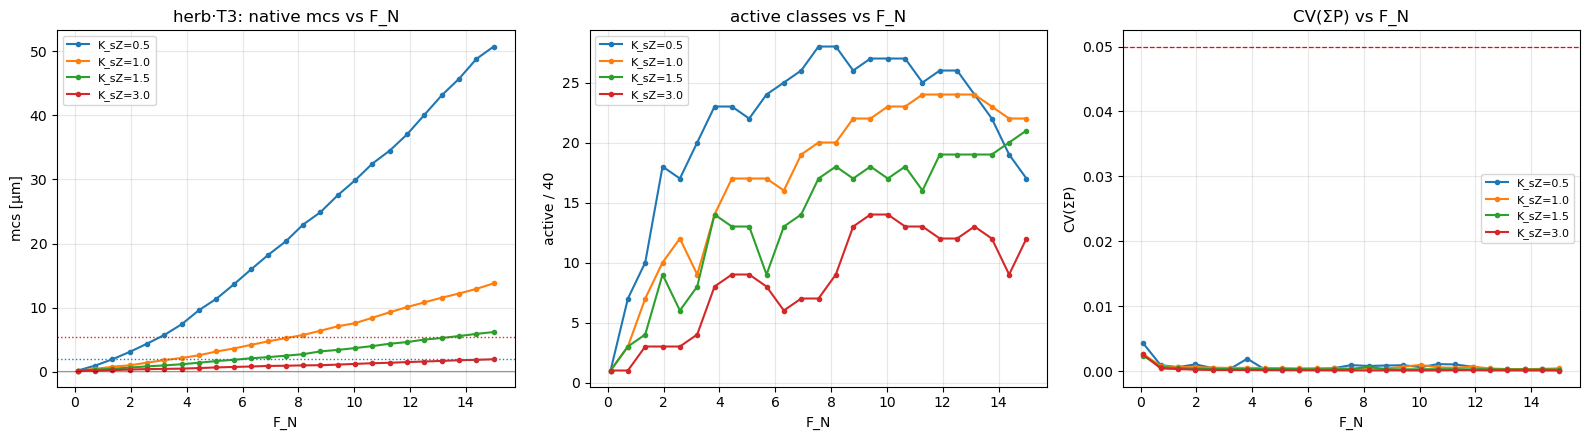

In [4]:
# ── Type III viability: sweep uniform K_sZ × F_N (herb kernel, N=40) ──────────
import importlib, numpy as np
import cariaco_obs as co, cariaco_baseline_setups as cbs, parscan_utils as pu
for m in (co, cbs, pu):
    importlib.reload(m)
from xso.parscans import run_xso_parscan
from parscan_utils import aggregate_model_to_targets, compute_phyto_spectrum_metrics
from cariaco_obs import TARGET_BIN_DEFINITIONS

phyto_esd, zoo_esd = cbs.phyto_esd, cbs.zoo_esd
n_Z = len(zoo_esd)
phyto_bin_defs = [b for b in TARGET_BIN_DEFINITIONS if b['type'] == 'phyto']
*_, f_all = co.load_cariaco_targets(regime='all', months='hplc', agg='median')
DE = f_all['Inflow__de']

KSZ_VALS   = [0.5, 1.0, 1.5, 3.0]          # uniform; Rohr-low → Stock/Banas
F_N_VALUES = np.linspace(0.1, 15, 25)
TAIL = 1000
def mcs_native(P):
    t = P.sum()
    return 10**np.sum((P/t)*np.log10(phyto_esd)) if t > 0 else np.nan

t3 = {}
for ksz in KSZ_VALS:
    ivp = run_xso_parscan(
        model_file_name='cariaco_baseline_setups', model_name='model_dist_t3',
        model_setup_name='model_setup_dist_herb_t3_slim',
        param_name='Inflow__FN', param_values=F_N_VALUES, processes=8,
        fixed_overrides={'Inflow__de': DE, 'Grazing__KsZ': np.full(n_Z, ksz)})
    n = ivp.sizes['Inflow__FN']
    mcs = np.full(n, np.nan); cen = np.full(n, np.nan)
    act = np.full(n, np.nan); cv = np.full(n, np.nan)
    for i in range(n):
        Pda = ivp.Phytoplankton__biomass.isel({'Inflow__FN': i})
        Pt = np.clip(Pda.isel(time=slice(-TAIL, None)).mean('time').values, 0, None)
        if not np.all(np.isfinite(Pt)):
            continue
        sP = Pda.sum('phyto').isel(time=slice(-TAIL, None)).values
        cv[i] = float(sP.std()/abs(sP.mean())) if sP.mean() != 0 else np.nan
        mcs[i] = mcs_native(Pt); act[i] = int((Pt > 1e-6).sum())
        vec = aggregate_model_to_targets({'phyto': Pt}, phyto_esd, zoo_esd, phyto_bin_defs)
        cen[i] = compute_phyto_spectrum_metrics(vec, phyto_bin_defs)['centroid']
    t3[ksz] = dict(mcs=mcs, cen=cen, act=act, cv=cv)
    print(f'K_sZ={ksz:>4}: mcs {np.nanmin(mcs):.2f}–{np.nanmax(mcs):.2f}µm  '
          f'active {int(np.nanmin(act))}–{int(np.nanmax(act))}/{len(phyto_esd)}  '
          f'CV {np.nanmin(cv):.3f}–{np.nanmax(cv):.3f}')

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
for ksz in KSZ_VALS:
    ax[0].plot(F_N_VALUES, t3[ksz]['mcs'], 'o-', ms=3, label=f'K_sZ={ksz}')
    ax[1].plot(F_N_VALUES, t3[ksz]['act'], 'o-', ms=3, label=f'K_sZ={ksz}')
    ax[2].plot(F_N_VALUES, t3[ksz]['cv'],  'o-', ms=3, label=f'K_sZ={ksz}')
ax[0].axhline(5.4, color='C3', ls=':', lw=1); ax[0].axhline(2.0, color='C0', ls=':', lw=1)
ax[0].axhline(0.2, color='k', lw=.8, alpha=.4)
ax[0].set(title='herb·T3: native mcs vs F_N', xlabel='F_N', ylabel='mcs [µm]')
ax[1].set(title='active classes vs F_N', xlabel='F_N', ylabel=f'active / {len(phyto_esd)}')
ax[2].axhline(0.05, color='red', ls='--', lw=.9)
ax[2].set(title='CV(ΣP) vs F_N', xlabel='F_N', ylabel='CV(ΣP)')
for a in ax: a.legend(fontsize=8); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3' and setup 'model_setup_dist_herb_t3_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 25 points using 8 workers...
1D Scan complete. Time taken: 16.55542 seconds.
K_sZ= 0.5: mcs 0.20–50.70µm  active 1–28/40  CV 0.000–0.004
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3' and setup 'model_setup_dist_herb_t3_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 25 points using 8 workers...
1D Scan complete. Time taken: 18.48176 seconds.
K_sZ= 1.0: mcs 0.20–13.79µm  active 1–24/40  CV 0.000–0.003
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3' and setup 'model_setup_dist_herb_t3_slim' from 'cariaco_baseline_setup

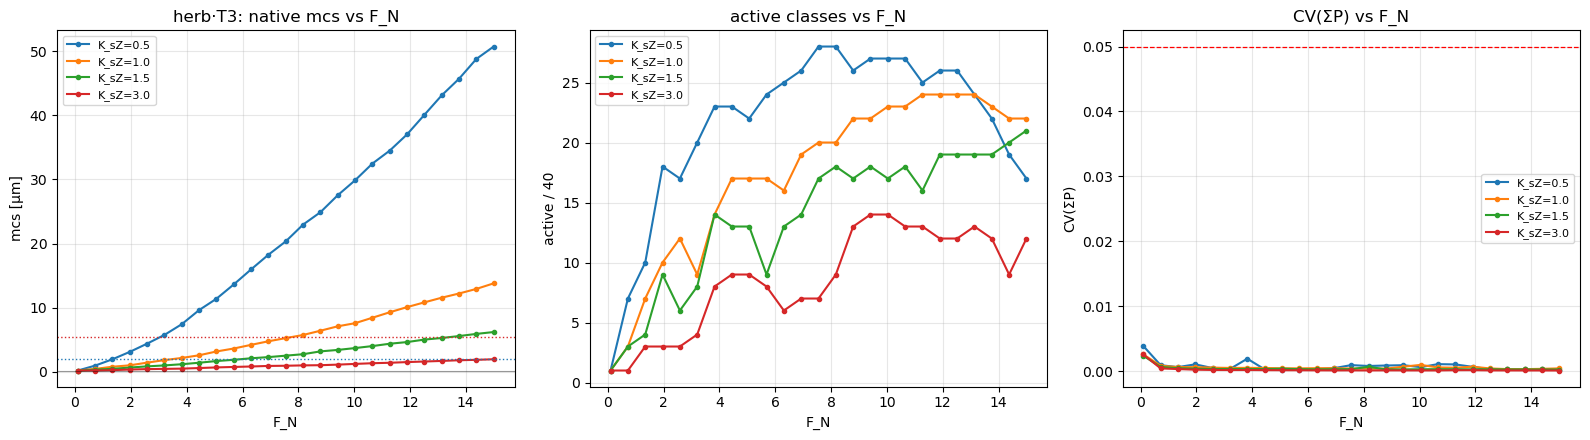

In [9]:
# ── Type III viability: sweep uniform K_sZ × F_N (herb kernel, N=40) ──────────
import importlib, numpy as np
import cariaco_obs as co, cariaco_baseline_setups as cbs, parscan_utils as pu
for m in (co, cbs, pu):
    importlib.reload(m)
from xso.parscans import run_xso_parscan
from parscan_utils import aggregate_model_to_targets, compute_phyto_spectrum_metrics
from cariaco_obs import TARGET_BIN_DEFINITIONS

phyto_esd, zoo_esd = cbs.phyto_esd, cbs.zoo_esd
n_Z = len(zoo_esd)
phyto_bin_defs = [b for b in TARGET_BIN_DEFINITIONS if b['type'] == 'phyto']
*_, f_all = co.load_cariaco_targets(regime='all', months='hplc', agg='median')
DE = f_all['Inflow__de']

KSZ_VALS   = [0.5, 1.0, 1.5, 3.0]          # uniform; Rohr-low → Stock/Banas
F_N_VALUES = np.linspace(0.1, 15, 25)
TAIL = 1000
def mcs_native(P):
    t = P.sum()
    return 10**np.sum((P/t)*np.log10(phyto_esd)) if t > 0 else np.nan

t3 = {}
for ksz in KSZ_VALS:
    ivp = run_xso_parscan(
        model_file_name='cariaco_baseline_setups', model_name='model_dist_t3',
        model_setup_name='model_setup_dist_herb_t3_slim',
        param_name='Inflow__FN', param_values=F_N_VALUES, processes=8,
        fixed_overrides={'Inflow__de': DE, 'Grazing__KsZ': np.full(n_Z, ksz)})
    n = ivp.sizes['Inflow__FN']
    mcs = np.full(n, np.nan); cen = np.full(n, np.nan)
    act = np.full(n, np.nan); cv = np.full(n, np.nan)
    for i in range(n):
        Pda = ivp.Phytoplankton__biomass.isel({'Inflow__FN': i})
        Pt = np.clip(Pda.isel(time=slice(-TAIL, None)).mean('time').values, 0, None)
        if not np.all(np.isfinite(Pt)):
            continue
        sP = Pda.sum('phyto').isel(time=slice(-TAIL, None)).values
        cv[i] = float(sP.std()/abs(sP.mean())) if sP.mean() != 0 else np.nan
        mcs[i] = mcs_native(Pt); act[i] = int((Pt > 1e-6).sum())
        vec = aggregate_model_to_targets({'phyto': Pt}, phyto_esd, zoo_esd, phyto_bin_defs)
        cen[i] = compute_phyto_spectrum_metrics(vec, phyto_bin_defs)['centroid']
    t3[ksz] = dict(mcs=mcs, cen=cen, act=act, cv=cv)
    print(f'K_sZ={ksz:>4}: mcs {np.nanmin(mcs):.2f}–{np.nanmax(mcs):.2f}µm  '
          f'active {int(np.nanmin(act))}–{int(np.nanmax(act))}/{len(phyto_esd)}  '
          f'CV {np.nanmin(cv):.3f}–{np.nanmax(cv):.3f}')

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
for ksz in KSZ_VALS:
    ax[0].plot(F_N_VALUES, t3[ksz]['mcs'], 'o-', ms=3, label=f'K_sZ={ksz}')
    ax[1].plot(F_N_VALUES, t3[ksz]['act'], 'o-', ms=3, label=f'K_sZ={ksz}')
    ax[2].plot(F_N_VALUES, t3[ksz]['cv'],  'o-', ms=3, label=f'K_sZ={ksz}')
ax[0].axhline(5.4, color='C3', ls=':', lw=1); ax[0].axhline(2.0, color='C0', ls=':', lw=1)
ax[0].axhline(0.2, color='k', lw=.8, alpha=.4)
ax[0].set(title='herb·T3: native mcs vs F_N', xlabel='F_N', ylabel='mcs [µm]')
ax[1].set(title='active classes vs F_N', xlabel='F_N', ylabel=f'active / {len(phyto_esd)}')
ax[2].axhline(0.05, color='red', ls='--', lw=.9)
ax[2].set(title='CV(ΣP) vs F_N', xlabel='F_N', ylabel='CV(ΣP)')
for a in ax: a.legend(fontsize=8); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [8]:
# ── herb·T3 @ literature K_sZ: convergence (40 vs 80) + eigenvalue stability ──
import importlib, numpy as np
import cariaco_obs as co, cariaco_baseline_setups as cbs, parscan_utils as pu
for m in (co, cbs, pu):
    importlib.reload(m)
from xso.parscans import run_xso_parscan, run_xso_stabilityscan
from parscan_utils import (extract_steady_state_seed, aggregate_model_to_targets,
                           compute_phyto_spectrum_metrics)
from cariaco_obs import TARGET_BIN_DEFINITIONS

phyto_esd, zoo_esd = cbs.phyto_esd, cbs.zoo_esd
N = len(phyto_esd)
phyto_bin_defs = [b for b in TARGET_BIN_DEFINITIONS if b['type'] == 'phyto']
*_, f_all = co.load_cariaco_targets(regime='all', months='hplc', agg='median')
DE = f_all['Inflow__de']

KSZ = 0.5                                    # uniform, literature window
F_N_VALUES = np.linspace(0.1, 15, 15)
AVG = 1000
ksz_arr = np.full(len(zoo_esd), KSZ)
fixed = {'Inflow__de': DE, 'Grazing__KsZ': ksz_arr}
def mcs_native(P):
    t = P.sum()
    return 10**np.sum((P/t)*np.log10(phyto_esd)) if t > 0 else np.nan

# Step 1 — IVP to tail-mean (centroid/mcs + seed for the solver)
ivp = run_xso_parscan(
    model_file_name='cariaco_baseline_setups', model_name='model_dist_t3',
    model_setup_name='model_setup_dist_herb_t3_slim',
    param_name='Inflow__FN', param_values=F_N_VALUES, processes=8,
    fixed_overrides=fixed, postprocess_name='avg_tail',
    postprocess_kwargs={'avg_window': AVG})
seed_ds, iv_map = extract_steady_state_seed(ivp, avg_window=AVG)

# Step 2 — stability solver seeded from the tail-mean (fsolve + eigenvalues)
stab = run_xso_stabilityscan(
    model_file_name='cariaco_baseline_setups', model_name='model_dist_t3',
    model_setup_name='model_setup_dist_herb_t3_stability',
    param_name='Inflow__FN', param_values=F_N_VALUES, processes=8,
    fixed_overrides=fixed, initial_values_ds=seed_ds, iv_mapping=iv_map)

n = len(F_N_VALUES)
cen = np.full(n, np.nan); mcs = np.full(n, np.nan); act = np.full(n, np.nan)
eig = np.full(n, np.nan); lab = np.empty(n, dtype=object)
for i in range(n):
    Pda = ivp.Phytoplankton__biomass.isel({'Inflow__FN': i})
    Pt = np.clip((Pda.mean('time') if 'time' in Pda.dims else Pda).values, 0, None)
    if np.all(np.isfinite(Pt)) and Pt.sum() > 0:
        mcs[i] = mcs_native(Pt); act[i] = int((Pt > 1e-6).sum())
        vec = aggregate_model_to_targets({'phyto': Pt}, phyto_esd, zoo_esd, phyto_bin_defs)
        cen[i] = compute_phyto_spectrum_metrics(vec, phyto_bin_defs)['centroid']
    if 'max_eigenvalue' in stab:
        eig[i] = float(stab.max_eigenvalue.isel({'Inflow__FN': i}).values)
    if 'stability' in stab:
        lab[i] = str(stab.stability.isel({'Inflow__FN': i}).values)

CONV = globals().get('CONV', {})
CONV[N] = dict(F_N=F_N_VALUES, cen=cen, mcs=mcs, act=act, eig=eig, lab=lab, ksz=KSZ)
globals()['CONV'] = CONV
print(f'N={N}, K_sZ={KSZ}: mcs {np.nanmin(mcs):.2f}–{np.nanmax(mcs):.2f}µm  '
      f'active {int(np.nanmin(act))}–{int(np.nanmax(act))}/{N}  '
      f'max Re(λ) [{np.nanmin(eig):.2e}, {np.nanmax(eig):.2e}]  '
      f'cells with Re(λ)<0: {int(np.nansum(eig < 0))}/{n}')
print(f'CONV has N = {sorted(CONV)}')
print('→ to fill CONV[80]: set N_CLASSES=80 in cariaco_baseline_setups.py, re-copy, re-run this cell.')

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3' and setup 'model_setup_dist_herb_t3_slim' from 'cariaco_baseline_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 15 points using 8 workers...
1D Scan complete. Time taken: 37.37026 seconds.
--- Starting Stability Scan ---
Validating model 'model_dist_t3' and setup 'model_setup_dist_herb_t3_stability' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
Injecting initial values from dataset using mapping: {'Nutrient__value': 'Nutrient__value_init', 'Phytoplankton__biomass': 'Phytoplankton__biomass_init', 'Zooplankton__biomass': 'Zooplankton__biomass_init'}
--------------------------------
Starting 1D stability scan of 'cariaco_baseline_setups' over 15 points using 8 workers...
[HOOK] Detected NumericalStabilitySolver - will capture stability results
[HOOK] Sys

[HOOK] Detected NumericalStabilitySolver - will capture stability results
[HOOK] System stability: STABLE
[HOOK] Max eigenvalue real part: -2.8353e-05
F_N=  2.0: CV(ΣP) mid=0.0005 end=0.0005 | maxRe(λ)=-2.84e-05 (stable, 0 pos) | fsolve-vs-tailmean rel.diff max=0.13 med=0.03
[HOOK] Detected NumericalStabilitySolver - will capture stability results
[HOOK] System stability: UNSTABLE
[HOOK] Max eigenvalue real part: 3.3212e-04
F_N=  6.0: CV(ΣP) mid=0.0006 end=0.0006 | maxRe(λ)=+3.32e-04 (unstable, 4 pos) | fsolve-vs-tailmean rel.diff max=8.82 med=1.00
[HOOK] Detected NumericalStabilitySolver - will capture stability results
[HOOK] System stability: UNSTABLE
[HOOK] Max eigenvalue real part: 1.7100e-03
F_N= 12.0: CV(ΣP) mid=0.0002 end=0.0001 | maxRe(λ)=+1.71e-03 (unstable, 7 pos) | fsolve-vs-tailmean rel.diff max=1.00 med=0.14


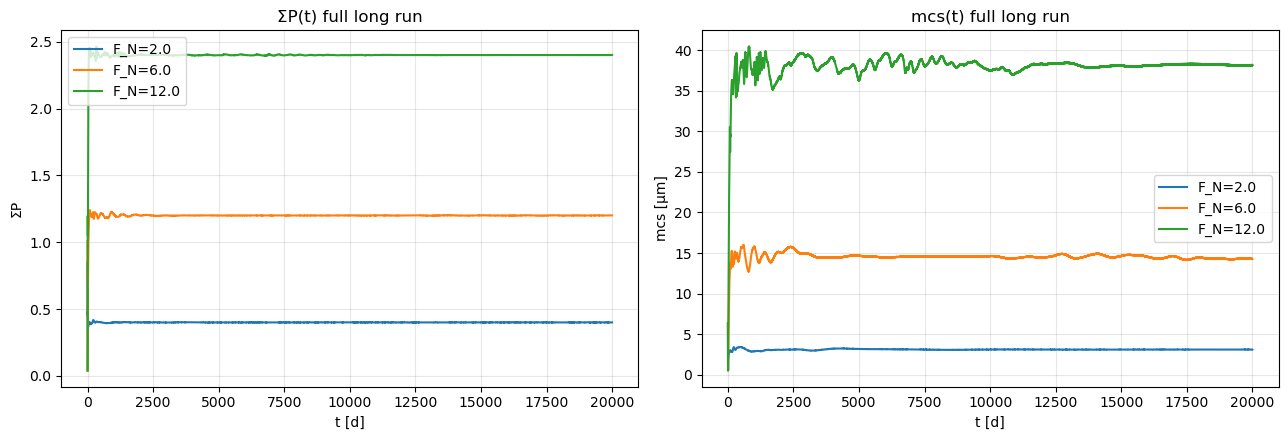

In [10]:
# ── Steady-state deep-dive: long IVP + seeded fsolve (herb·T3, K_sZ=0.5) ──────
import importlib, numpy as np, matplotlib.pyplot as plt
import cariaco_baseline_comps as cbc, cariaco_baseline_setups as cbs
import cariaco_obs as co, run_baseline_diagnostic as rbd
for m in (cbc, cbs, co, rbd):
    importlib.reload(m)
import xso
from xso.parscans import StabilityAnalysisHook

pe, ze = cbs.phyto_esd, cbs.zoo_esd
logpe = np.log10(pe)
KSZ = 0.5; ksz_arr = np.full(len(ze), KSZ)
*_, f_all = co.load_cariaco_targets(regime='all', months='hplc', agg='median')
DE = f_all['Inflow__de']
FN_LIST = [2.0, 6.0, 12.0]
T_LONG = 20000

long_setup = xso.setup(solver='solve_ivp', model=cbs.model_dist_t3,
                       time=np.arange(0, T_LONG, 1),
                       input_vars=cbs.make_dist_input_vars(cbs.phiPZ_herb),
                       solver_kwargs=cbs.IVP_SOLVER_KWARGS)
stab_setup = xso.setup(solver='stability', model=cbs.model_dist_t3, time=[0, 1],
                       input_vars=cbs.make_dist_input_vars(cbs.phiPZ_herb))

def mcs_series(P):
    tot = P.sum(0)
    fr = P / np.where(tot > 0, tot, 1.0)[None, :]
    return 10**(fr * logpe[:, None]).sum(0)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for fn in FN_LIST:
    out = rbd.run_setup(cbs.model_dist_t3, long_setup,
                        input_vars_override={'Inflow': {'FN': fn, 'de': DE},
                                             'Grazing': {'KsZ': ksz_arr}})
    st = rbd.extract_state(out); P, t = st['P'], st['t']
    sumP = P.sum(0); mcs_t = mcs_series(P)
    w = len(t) // 5
    cv_mid = sumP[len(t)//2:len(t)//2+w].std()/abs(sumP[len(t)//2:len(t)//2+w].mean())
    cv_end = sumP[-w:].std()/abs(sumP[-w:].mean())
    P_tail = P[:, -5000:].mean(1); N_tail = float(st['N'][-5000:].mean())
    Z_tail = st['Z'][:, -5000:].mean(1)
    hook = StabilityAnalysisHook()
    with cbs.model_dist_t3:
        so = (stab_setup.xsimlab.update_vars(input_vars={
                'Nutrient': {'value_init': N_tail},
                'Phytoplankton': {'biomass_init': P_tail},
                'Zooplankton': {'biomass_init': Z_tail},
                'Inflow': {'FN': fn, 'de': DE},
                'Grazing': {'KsZ': ksz_arr}})
              .xsimlab.run(hooks=[hook]))
    sd = hook.get_results()
    P_fix = np.clip(so['Phytoplankton__biomass'].isel(time=-1).values, 0, None)
    act = P_tail > 1e-6
    rel = np.abs(P_fix[act] - P_tail[act]) / np.abs(P_tail[act])
    print(f"F_N={fn:5.1f}: CV(ΣP) mid={cv_mid:.4f} end={cv_end:.4f} | "
          f"maxRe(λ)={sd.get('max_eigenvalue_real', float('nan')):+.2e} "
          f"({sd.get('stability','?')}, {sd.get('n_positive_eigenvalues','?')} pos) | "
          f"fsolve-vs-tailmean rel.diff max={np.nanmax(rel):.2f} med={np.nanmedian(rel):.2f}")
    ax[0].plot(t, sumP, label=f'F_N={fn}')
    ax[1].plot(t, mcs_t, label=f'F_N={fn}')
ax[0].set(title='ΣP(t) full long run', xlabel='t [d]', ylabel='ΣP'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].set(title='mcs(t) full long run', xlabel='t [d]', ylabel='mcs [µm]'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

In [12]:
# ── Biomass-weighted IC-robustness re-check (herb·T3, K_sZ=0.5) ───────────────
import importlib, numpy as np
import cariaco_baseline_setups as cbs, cariaco_obs as co, run_baseline_diagnostic as rbd
from parscan_utils import aggregate_model_to_targets
from cariaco_obs import TARGET_BIN_DEFINITIONS
for m in (cbs, co, rbd):
    importlib.reload(m)
import xso

pe, ze = cbs.phyto_esd, cbs.zoo_esd; logpe = np.log10(pe)
phyto_bin_defs = [b for b in TARGET_BIN_DEFINITIONS if b['type'] == 'phyto']
KSZ = 0.5; ksz_arr = np.full(len(ze), KSZ)
*_, f_all = co.load_cariaco_targets(regime='all', months='hplc', agg='median'); DE = f_all['Inflow__de']
setup10k = xso.setup(solver='solve_ivp', model=cbs.model_dist_t3, time=np.arange(0, 10000, 1),
                     input_vars=cbs.make_dist_input_vars(cbs.phiPZ_herb),
                     solver_kwargs=cbs.IVP_SOLVER_KWARGS)
def run_ic(fn, P0, Z0, N0=1.0):
    ov = {'Inflow': {'FN': fn, 'de': DE}, 'Grazing': {'KsZ': ksz_arr},
          'Phytoplankton': {'biomass_init': P0}, 'Zooplankton': {'biomass_init': Z0},
          'Nutrient': {'value_init': float(N0)}}
    st = rbd.extract_state(rbd.run_setup(cbs.model_dist_t3, setup10k, input_vars_override=ov))
    return st['P'][:, -2000:].mean(1), st['Z'][:, -2000:].mean(1)
def mcs(P): t = P.sum(); return 10**np.sum((P/t)*logpe) if t > 0 else np.nan
def fracs(P):
    v = np.asarray(aggregate_model_to_targets({'phyto': P}, pe, ze, phyto_bin_defs), float)
    return v/v.sum()

for fn in [6.0, 12.0]:
    Pr, Zr = run_ic(fn, np.full(len(pe), 1e-3), np.full(len(ze), 1e-3))
    pr = Pr/Pr.sum(); fr = fracs(Pr)
    print(f"\nF_N={fn}: REF mcs={mcs(Pr):.2f}µm ΣP={Pr.sum():.3f} "
          f"Pico/Nano/Micro={fr[0]:.3f}/{fr[1]:.3f}/{fr[2]:.3f}")
    for tag, (P0, Z0) in {
        '×0.5':       (np.clip(Pr*0.5, 1e-9, None), np.clip(Zr*0.5, 1e-9, None)),
        '×2':         (np.clip(Pr*2.0, 1e-9, None), np.clip(Zr*2.0, 1e-9, None)),
        'uniform-hi': (np.full(len(pe), 0.05),       np.full(len(ze), 0.05)),
    }.items():
        Pf, _ = run_ic(fn, P0, Z0)
        tvd = 0.5*np.sum(np.abs(Pf/Pf.sum() - pr))     # 0=identical, 1=disjoint
        ff = fracs(Pf)
        print(f"  IC {tag:10s}: mcs={mcs(Pf):.2f}µm  TVD(spectrum)={tvd:.4f}  "
              f"Pico/Nano/Micro={ff[0]:.3f}/{ff[1]:.3f}/{ff[2]:.3f}")


F_N=6.0: REF mcs=14.55µm ΣP=1.200 Pico/Nano/Micro=0.148/0.349/0.503
  IC ×0.5      : mcs=14.32µm  TVD(spectrum)=0.1556  Pico/Nano/Micro=0.154/0.324/0.522
  IC ×2        : mcs=14.38µm  TVD(spectrum)=0.1484  Pico/Nano/Micro=0.154/0.327/0.519
  IC uniform-hi: mcs=14.57µm  TVD(spectrum)=0.0426  Pico/Nano/Micro=0.153/0.344/0.504

F_N=12.0: REF mcs=38.30µm ΣP=2.400 Pico/Nano/Micro=0.091/0.139/0.770
  IC ×0.5      : mcs=38.29µm  TVD(spectrum)=0.3627  Pico/Nano/Micro=0.083/0.138/0.780
  IC ×2        : mcs=38.30µm  TVD(spectrum)=0.3631  Pico/Nano/Micro=0.083/0.137/0.780
  IC uniform-hi: mcs=38.17µm  TVD(spectrum)=0.3000  Pico/Nano/Micro=0.086/0.138/0.776


--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3' and setup 'model_setup_dist_herb_t3_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 20 points using 8 workers...
1D Scan complete. Time taken: 16.81313 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3' and setup 'model_setup_dist_omni_t3_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 20 points using 8 workers...
1D Scan complete. Time taken: 20.09931 seconds.


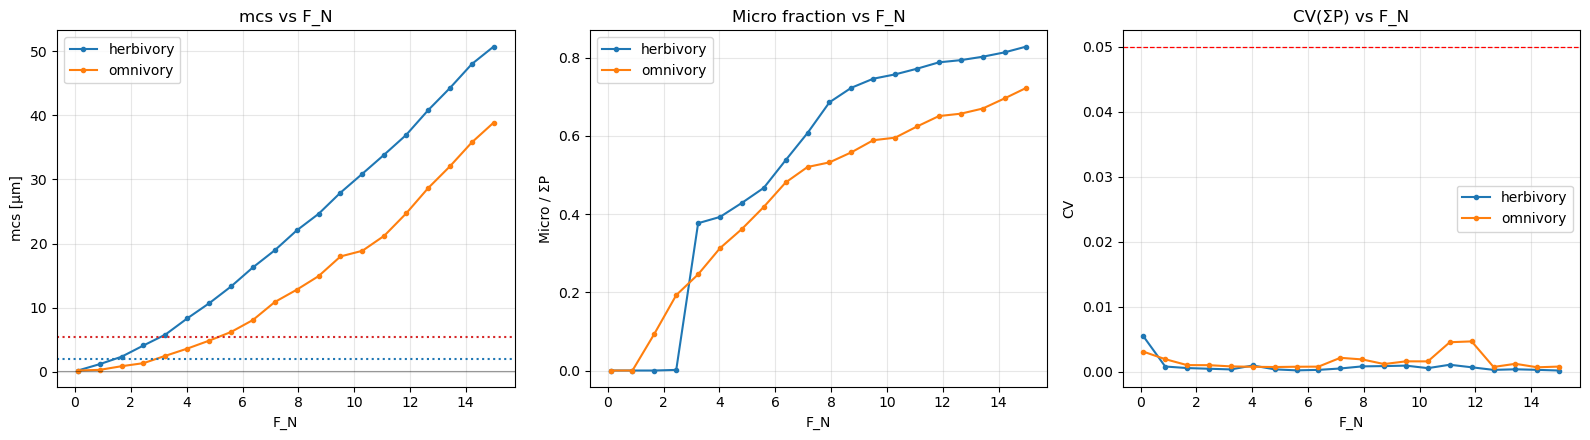

herb: mcs 0.20–50.70µm  CV 0.000–0.005  active 1–28
omni: mcs 0.20–38.85µm  CV 0.001–0.005  active 1–29


In [13]:
# ── Omnivory (intraguild predation) vs herbivory on the size spectrum ─────────
import matplotlib.pyplot as plt
from xso.parscans import run_xso_parscan
from parscan_utils import compute_phyto_spectrum_metrics
F_N_VALUES = np.linspace(0.1, 15, 20); TAIL = 1000
def curve(setup_name):
    ivp = run_xso_parscan(model_file_name='cariaco_baseline_setups', model_name='model_dist_t3',
        model_setup_name=setup_name, param_name='Inflow__FN', param_values=F_N_VALUES, processes=8,
        fixed_overrides={'Inflow__de': DE, 'Grazing__KsZ': ksz_arr})
    n = ivp.sizes['Inflow__FN']
    out = {k: np.full(n, np.nan) for k in ('mcs', 'micro', 'cv', 'act')}
    for i in range(n):
        Pda = ivp.Phytoplankton__biomass.isel({'Inflow__FN': i})
        Pt = np.clip(Pda.isel(time=slice(-TAIL, None)).mean('time').values, 0, None)
        if not (np.all(np.isfinite(Pt)) and Pt.sum() > 0):
            continue
        sP = Pda.sum('phyto').isel(time=slice(-TAIL, None)).values
        out['cv'][i] = sP.std()/abs(sP.mean()); out['act'][i] = int((Pt > 1e-6).sum())
        out['mcs'][i] = 10**np.sum((Pt/Pt.sum())*logpe)
        out['micro'][i] = compute_phyto_spectrum_metrics(
            aggregate_model_to_targets({'phyto': Pt}, pe, ze, phyto_bin_defs), phyto_bin_defs)['fractions'][2]
    return out
herb, omni = curve('model_setup_dist_herb_t3_slim'), curve('model_setup_dist_omni_t3_slim')

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
for nm, d, c in [('herbivory', herb, 'C0'), ('omnivory', omni, 'C1')]:
    ax[0].plot(F_N_VALUES, d['mcs'], 'o-', ms=3, color=c, label=nm)
    ax[1].plot(F_N_VALUES, d['micro'], 'o-', ms=3, color=c, label=nm)
    ax[2].plot(F_N_VALUES, d['cv'], 'o-', ms=3, color=c, label=nm)
ax[0].axhline(5.4, color='C3', ls=':'); ax[0].axhline(2.0, color='C0', ls=':'); ax[0].axhline(0.2, color='k', lw=.8, alpha=.4)
ax[0].set(title='mcs vs F_N', xlabel='F_N', ylabel='mcs [µm]')
ax[1].set(title='Micro fraction vs F_N', xlabel='F_N', ylabel='Micro / ΣP')
ax[2].axhline(0.05, color='red', ls='--', lw=.9); ax[2].set(title='CV(ΣP) vs F_N', xlabel='F_N', ylabel='CV')
for a in ax:
    a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.show()
for nm, d in [('herb', herb), ('omni', omni)]:
    print(f"{nm}: mcs {np.nanmin(d['mcs']):.2f}–{np.nanmax(d['mcs']):.2f}µm  "
          f"CV {np.nanmin(d['cv']):.3f}–{np.nanmax(d['cv']):.3f}  "
          f"active {int(np.nanmin(d['act']))}–{int(np.nanmax(d['act']))}")

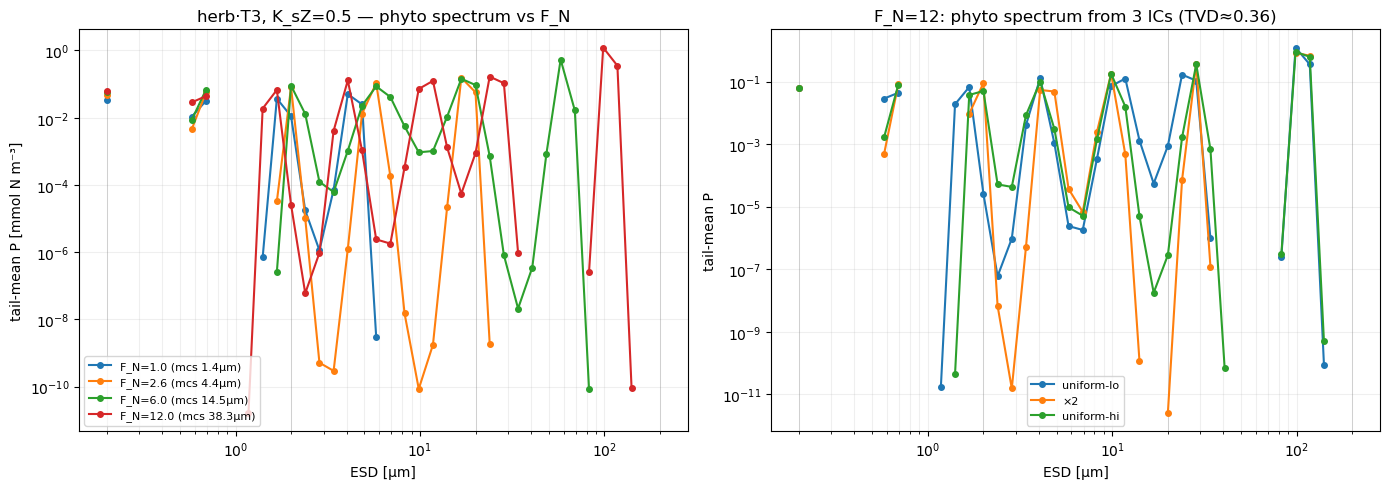

In [14]:
# ── Plot Type III phyto spectra (herb·T3, K_sZ=0.5): vs F_N + IC overlay ──────
import importlib, numpy as np, matplotlib.pyplot as plt
import cariaco_baseline_setups as cbs, cariaco_obs as co, run_baseline_diagnostic as rbd
for m in (cbs, co, rbd):
    importlib.reload(m)
import xso

pe, ze = cbs.phyto_esd, cbs.zoo_esd
KSZ = 0.5; ksz_arr = np.full(len(ze), KSZ)
*_, f_all = co.load_cariaco_targets(regime='all', months='hplc', agg='median'); DE = f_all['Inflow__de']
setup10k = xso.setup(solver='solve_ivp', model=cbs.model_dist_t3, time=np.arange(0, 10000, 1),
                     input_vars=cbs.make_dist_input_vars(cbs.phiPZ_herb), solver_kwargs=cbs.IVP_SOLVER_KWARGS)
def run(fn, P0=None, Z0=None):
    ov = {'Inflow': {'FN': fn, 'de': DE}, 'Grazing': {'KsZ': ksz_arr}}
    if P0 is not None:
        ov['Phytoplankton'] = {'biomass_init': P0}; ov['Zooplankton'] = {'biomass_init': Z0}
    st = rbd.extract_state(rbd.run_setup(cbs.model_dist_t3, setup10k, input_vars_override=ov))
    return st['P'][:, -2000:].mean(1), st['Z'][:, -2000:].mean(1)
def mcs(P): t = P.sum(); return 10**np.sum((P/t)*np.log10(pe)) if t > 0 else np.nan

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for axx in ax:
    for v in (0.2, 2, 20, 200):
        axx.axvline(v, color='grey', lw=.5, alpha=.4)

# (a) spectrum vs F_N (default IC)
for fn in [1.0, 2.6, 6.0, 12.0]:
    P, _ = run(fn)
    ax[0].loglog(pe, np.where(P > 1e-12, P, np.nan), 'o-', ms=4,
                 label=f'F_N={fn} (mcs {mcs(P):.1f}µm)')
ax[0].set(title='herb·T3, K_sZ=0.5 — phyto spectrum vs F_N',
          xlabel='ESD [µm]', ylabel='tail-mean P [mmol N m⁻³]')
ax[0].legend(fontsize=8); ax[0].grid(alpha=.2, which='both')

# (b) IC overlay at F_N=12 (the TVD~0.36 case)
Pr, Zr = run(12.0)
for tag, (P0, Z0) in {'uniform-lo': (np.full(len(pe), 1e-3), np.full(len(ze), 1e-3)),
                      '×2': (np.clip(Pr*2, 1e-9, None), np.clip(Zr*2, 1e-9, None)),
                      'uniform-hi': (np.full(len(pe), 0.05), np.full(len(ze), 0.05))}.items():
    P, _ = run(12.0, P0, Z0)
    ax[1].loglog(pe, np.where(P > 1e-12, P, np.nan), 'o-', ms=4, label=tag)
ax[1].set(title='F_N=12: phyto spectrum from 3 ICs (TVD≈0.36)',
          xlabel='ESD [µm]', ylabel='tail-mean P')
ax[1].legend(fontsize=8); ax[1].grid(alpha=.2, which='both')
plt.tight_layout(); plt.show()

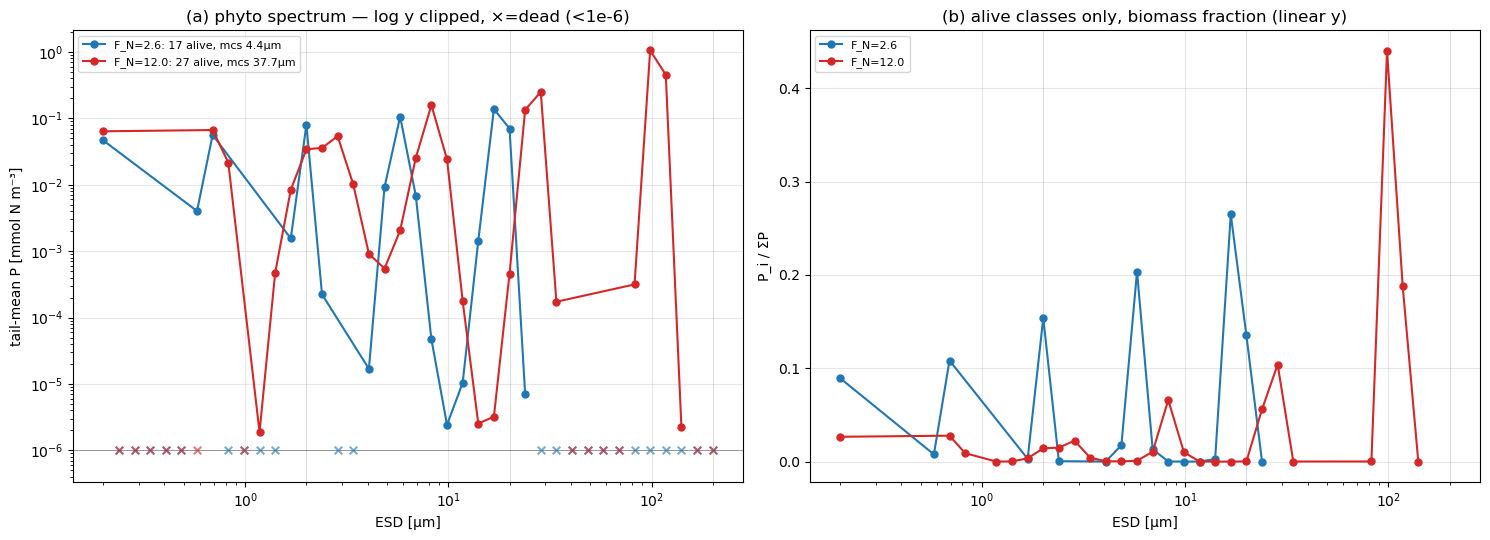

tail-mean of last 1000 d of a 5000 d run = realized steady state (CV(ΣP)~1e-4).


In [15]:
# ── Cleaner Type III spectrum: 5000 d run, tail-mean, dead classes marked ─────
import importlib, numpy as np, matplotlib.pyplot as plt
import cariaco_baseline_setups as cbs, cariaco_obs as co, run_baseline_diagnostic as rbd
for m in (cbs, co, rbd):
    importlib.reload(m)
import xso

pe, ze = cbs.phyto_esd, cbs.zoo_esd
KSZ = 0.5; ksz_arr = np.full(len(ze), KSZ); FLOOR = 1e-6
*_, f_all = co.load_cariaco_targets(regime='all', months='hplc', agg='median'); DE = f_all['Inflow__de']
setup5k = xso.setup(solver='solve_ivp', model=cbs.model_dist_t3, time=np.arange(0, 5000, 1),
                    input_vars=cbs.make_dist_input_vars(cbs.phiPZ_herb), solver_kwargs=cbs.IVP_SOLVER_KWARGS)
def tailmean(fn, tail=1000):
    st = rbd.extract_state(rbd.run_setup(cbs.model_dist_t3, setup5k,
            input_vars_override={'Inflow': {'FN': fn, 'de': DE}, 'Grazing': {'KsZ': ksz_arr}}))
    return st['P'][:, -tail:].mean(1)
def mcs(P):
    a = P > FLOOR; t = P[a].sum()
    return 10**np.sum((P[a]/t)*np.log10(pe[a])) if t > 0 else np.nan

FNs = [2.6, 12.0]; cols = ['C0', 'C3']
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
for axx in ax:
    axx.set_xscale('log')
    for v in (2, 20, 200):
        axx.axvline(v, color='grey', lw=.5, alpha=.4)
for fn, c in zip(FNs, cols):
    P = tailmean(fn); alive = P > FLOOR
    ax[0].plot(pe[alive], P[alive], 'o-', color=c, ms=5,
               label=f'F_N={fn}: {alive.sum()} alive, mcs {mcs(P):.1f}µm')
    ax[0].scatter(pe[~alive], np.full((~alive).sum(), FLOOR), marker='x', color=c, s=30, alpha=.6)
    ax[1].plot(pe[alive], P[alive]/P.sum(), 'o-', color=c, ms=5, label=f'F_N={fn}')
ax[0].set_yscale('log'); ax[0].set_ylim(FLOOR/3, None)
ax[0].axhline(FLOOR, color='k', lw=.6, alpha=.4)
ax[0].set(title='(a) phyto spectrum — log y clipped, ×=dead (<1e-6)',
          xlabel='ESD [µm]', ylabel='tail-mean P [mmol N m⁻³]')
ax[1].set(title='(b) alive classes only, biomass fraction (linear y)',
          xlabel='ESD [µm]', ylabel='P_i / ΣP')
for a in ax:
    a.legend(fontsize=8); a.grid(alpha=.3)
plt.tight_layout(); plt.show()
print('tail-mean of last 1000 d of a 5000 d run = realized steady state (CV(ΣP)~1e-4).')

/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=125.8 on P[0] = -2.49. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


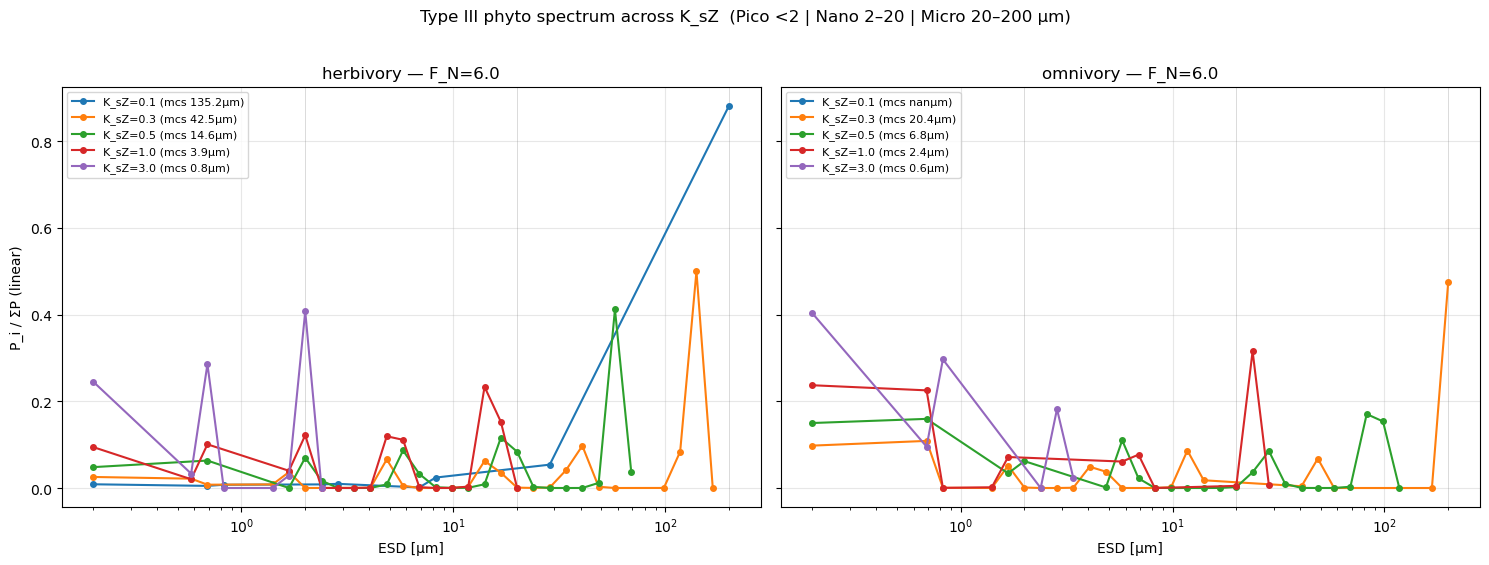

In [16]:
# ── Spectrum shape across K_sZ × {herbivory, omnivory} at fixed F_N ──────────
import importlib, numpy as np, matplotlib.pyplot as plt
import cariaco_baseline_setups as cbs, cariaco_obs as co, run_baseline_diagnostic as rbd
for m in (cbs, co, rbd):
    importlib.reload(m)
import xso

pe, ze = cbs.phyto_esd, cbs.zoo_esd; FLOOR = 1e-6
*_, f_all = co.load_cariaco_targets(regime='all', months='hplc', agg='median'); DE = f_all['Inflow__de']
FN = 6.0
KSZ_LIST = [0.1, 0.3, 0.5, 1.0, 3.0]
setups = {
    'herbivory': xso.setup(solver='solve_ivp', model=cbs.model_dist_t3, time=np.arange(0, 5000, 1),
                           input_vars=cbs.make_dist_input_vars(cbs.phiPZ_herb), solver_kwargs=cbs.IVP_SOLVER_KWARGS),
    'omnivory':  xso.setup(solver='solve_ivp', model=cbs.model_dist_t3, time=np.arange(0, 5000, 1),
                           input_vars=cbs.make_dist_input_vars(cbs.phiPZ_omni), solver_kwargs=cbs.IVP_SOLVER_KWARGS),
}
def mcs(P): a = P > FLOOR; t = P[a].sum(); return 10**np.sum((P[a]/t)*np.log10(pe[a])) if t > 0 else np.nan

fig, ax = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
for axx, (name, stp) in zip(ax, setups.items()):
    axx.set_xscale('log')
    for v in (2, 20, 200):
        axx.axvline(v, color='grey', lw=.5, alpha=.4)
    for ksz in KSZ_LIST:
        ov = {'Inflow': {'FN': FN, 'de': DE}, 'Grazing': {'KsZ': np.full(len(ze), ksz)}}
        st = rbd.extract_state(rbd.run_setup(cbs.model_dist_t3, stp, input_vars_override=ov))
        P = st['P'][:, -1000:].mean(1); a = P > FLOOR
        axx.plot(pe[a], P[a]/P.sum(), 'o-', ms=4, label=f'K_sZ={ksz} (mcs {mcs(P):.1f}µm)')
    axx.set(title=f'{name} — F_N={FN}', xlabel='ESD [µm]'); axx.legend(fontsize=8); axx.grid(alpha=.3)
ax[0].set_ylabel('P_i / ΣP (linear)')
plt.suptitle('Type III phyto spectrum across K_sZ  (Pico <2 | Nano 2–20 | Micro 20–200 µm)', y=1.02)
plt.tight_layout(); plt.show()

In [11]:
# ── IC robustness / return-to-attractor + tolerance check (herb·T3, K_sZ=0.5) ─
import importlib, numpy as np
import cariaco_baseline_setups as cbs, cariaco_obs as co, run_baseline_diagnostic as rbd
for m in (cbs, co, rbd):
    importlib.reload(m)
import xso

pe, ze = cbs.phyto_esd, cbs.zoo_esd; logpe = np.log10(pe)
KSZ = 0.5; ksz_arr = np.full(len(ze), KSZ)
*_, f_all = co.load_cariaco_targets(regime='all', months='hplc', agg='median')
DE = f_all['Inflow__de']
def mcs(P):
    t = P.sum(); return 10**np.sum((P/t)*logpe) if t > 0 else np.nan

def make_setup(skw):
    return xso.setup(solver='solve_ivp', model=cbs.model_dist_t3, time=np.arange(0, 10000, 1),
                     input_vars=cbs.make_dist_input_vars(cbs.phiPZ_herb), solver_kwargs=skw)
setup_loose = make_setup(cbs.IVP_SOLVER_KWARGS)
TIGHT = {**cbs.IVP_SOLVER_KWARGS, 'atol': 1e-9, 'rtol': 1e-7}
setup_tight = make_setup(TIGHT)

def run_ic(setup, fn, P0, Z0, N0=1.0):
    ov = {'Inflow': {'FN': fn, 'de': DE}, 'Grazing': {'KsZ': ksz_arr},
          'Phytoplankton': {'biomass_init': P0}, 'Zooplankton': {'biomass_init': Z0},
          'Nutrient': {'value_init': float(N0)}}
    st = rbd.extract_state(rbd.run_setup(cbs.model_dist_t3, setup, input_vars_override=ov))
    return st['P'][:, -2000:].mean(1), st['Z'][:, -2000:].mean(1), st

for fn in [6.0, 12.0]:
    Pr, Zr, st = run_ic(setup_loose, fn, np.full(len(pe), 1e-3), np.full(len(ze), 1e-3))
    print(f"\nF_N={fn}: reference (uniform-lo IC)  mcs={mcs(Pr):.2f}µm  ΣP={Pr.sum():.3f}")
    act = Pr > 1e-6
    for tag, (P0, Z0) in {
        '×0.5':       (np.clip(Pr*0.5, 1e-9, None), np.clip(Zr*0.5, 1e-9, None)),
        '×2':         (np.clip(Pr*2.0, 1e-9, None), np.clip(Zr*2.0, 1e-9, None)),
        'uniform-hi': (np.full(len(pe), 0.05),       np.full(len(ze), 0.05)),
    }.items():
        Pf, _, _ = run_ic(setup_loose, fn, P0, Z0)
        d = np.nanmax(np.abs(Pf[act]-Pr[act])/Pr[act])
        print(f"  IC {tag:10s}: mcs={mcs(Pf):.2f}µm  ΣP={Pf.sum():.3f}  max rel.diff to ref={d:.3f}")
    # tolerance: does the tiny residual shrink with a much tighter solver?
    Ptt, _, stt = run_ic(setup_tight, fn, np.full(len(pe), 1e-3), np.full(len(ze), 1e-3))
    cvl = (lambda s: s.std()/abs(s.mean()))(st['P'].sum(0)[-2000:])
    cvt = (lambda s: s.std()/abs(s.mean()))(stt['P'].sum(0)[-2000:])
    print(f"  CV(ΣP) loose(rtol1e-4)={cvl:.5f}  tight(rtol1e-7)={cvt:.5f}  "
          f"→ {'numerical' if cvt < cvl*0.5 else 'dynamical'} residual")


F_N=6.0: reference (uniform-lo IC)  mcs=14.55µm  ΣP=1.200
  IC ×0.5      : mcs=14.32µm  ΣP=1.200  max rel.diff to ref=13.921
  IC ×2        : mcs=14.38µm  ΣP=1.200  max rel.diff to ref=15.413
  IC uniform-hi: mcs=14.57µm  ΣP=1.200  max rel.diff to ref=2.635
  CV(ΣP) loose(rtol1e-4)=0.00020  tight(rtol1e-7)=0.00007  → numerical residual

F_N=12.0: reference (uniform-lo IC)  mcs=38.30µm  ΣP=2.400
  IC ×0.5      : mcs=38.29µm  ΣP=2.400  max rel.diff to ref=3525.994
  IC ×2        : mcs=38.30µm  ΣP=2.400  max rel.diff to ref=3464.055
  IC uniform-hi: mcs=38.17µm  ΣP=2.400  max rel.diff to ref=1934.018
  CV(ΣP) loose(rtol1e-4)=0.00057  tight(rtol1e-7)=0.00055  → dynamical residual


ValueError: x and y must have same first dimension, but have shapes (25,) and (10,)

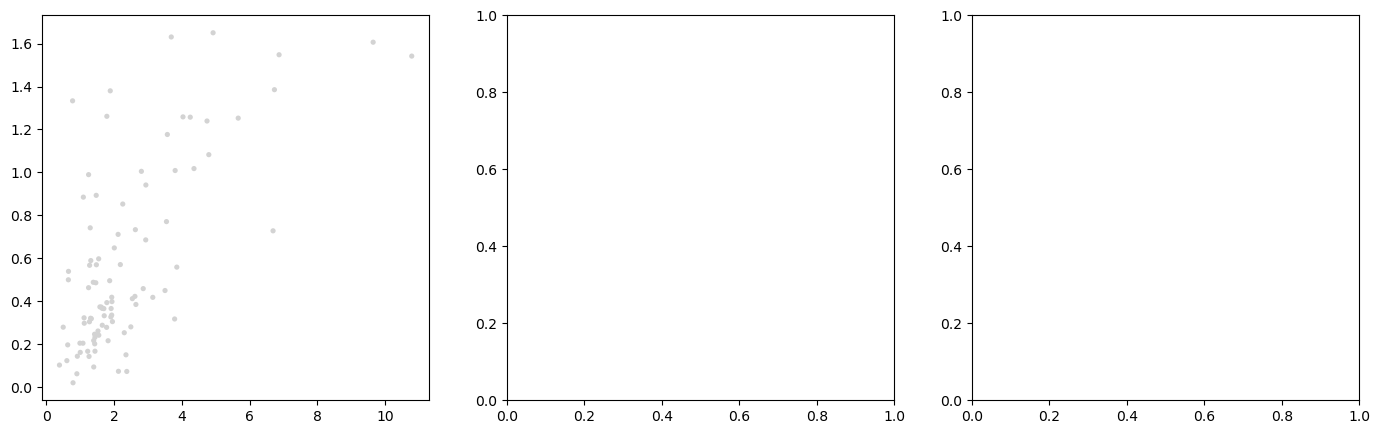

In [5]:
# ── Plot: size spectrum vs F_N, all 6 constructs, over obs ───────────────────
import matplotlib.pyplot as plt, pandas as pd
from cariaco_obs import DEFAULT_CSV_PATH

obs = pd.read_csv(DEFAULT_CSV_PATH).dropna(subset=['size_centroid', 'FN_mmolN_m2_d'])
COL = {'matched': 'C7', 'herb': 'C0', 'omni': 'C1'}
LS  = {'t2': '-', 't3': '--'}

fig, ax = plt.subplots(1, 3, figsize=(17, 5))
# (a) binned centroid vs F_N (obs-comparable) over obs scatter
ax[0].scatter(obs['FN_mmolN_m2_d'], obs['size_centroid'], s=14, c='lightgray',
              edgecolor='none', label='Cariaco obs', zorder=0)
for cname, d in curves.items():
    mode, resp = cname.split('_')
    ax[0].plot(F_N_VALUES, d['cen'], LS[resp], color=COL[mode], lw=2, label=cname)
ax[0].set(title='(a) binned centroid vs F_N (vs obs)', xlabel='F_N [mmol N m⁻² d⁻¹]',
          ylabel='size centroid')
ax[0].legend(fontsize=7, ncol=2); ax[0].grid(alpha=0.3)
# (b) native mean cell size vs F_N
for cname, d in curves.items():
    mode, resp = cname.split('_')
    ax[1].plot(F_N_VALUES, d['mcs'], LS[resp], color=COL[mode], lw=2, label=cname)
for axx in (ax[1],):
    axx.axhline(5.4, color='C3', ls=':', lw=1, alpha=.6); axx.axhline(2.0, color='C0', ls=':', lw=1, alpha=.6)
    axx.axhline(0.2, color='k', lw=.8, alpha=.4)
ax[1].set(title='(b) native mcs vs F_N (dotted=obs up/rel, black=floor)',
          xlabel='F_N [mmol N m⁻² d⁻¹]', ylabel='native mcs [µm]')
ax[1].legend(fontsize=7, ncol=2); ax[1].grid(alpha=0.3)
# (c) CV(ΣP) vs F_N — oscillation amplitude
for cname, d in curves.items():
    mode, resp = cname.split('_')
    ax[2].plot(F_N_VALUES, d['cv'], LS[resp], color=COL[mode], lw=2, label=cname)
ax[2].axhline(0.05, color='red', ls='--', lw=.9)
ax[2].set(title='(c) CV(ΣP) vs F_N (>0.05 = oscillating)',
          xlabel='F_N [mmol N m⁻² d⁻¹]', ylabel='CV(ΣP)')
ax[2].legend(fontsize=7, ncol=2); ax[2].grid(alpha=0.3)
for axx in ax:
    axx.axvline(2.58, color='C0', lw=.7, alpha=.5); axx.axvline(1.45, color='C2', lw=.7, alpha=.5)
plt.tight_layout(); plt.show()

In [3]:
# ── Type III diagnostic: allometric vs uniform K_sZ at high F_N (N=40) ────────
import importlib, numpy as np
import cariaco_baseline_comps as cbc, cariaco_baseline_setups as cbs
import cariaco_obs as co, run_baseline_diagnostic as rbd
for m in (cbc, cbs, co, rbd):
    importlib.reload(m)

pe, ze = cbs.phyto_esd, cbs.zoo_esd
n_P, n_Z = len(pe), len(ze)
phi = cbc.compute_grazing_kernel(pe, ze, 'herb', cbs.THETA_OPT, cbs.SIGMA_LOG)
*_, f_all = co.load_cariaco_targets(regime='all', months='hplc', agg='median')
DE, FN = f_all['Inflow__de'], 12.0          # high end of the obs F_N range

def run_t3(KsZ):
    ov = {'Inflow': {'FN': FN, 'de': DE}, 'Grazing': {'KsZ': KsZ}}
    out = rbd.run_setup(cbs.model_dist_t3, cbs.model_setup_dist_herb_t3_slim,
                        input_vars_override=ov)
    st = rbd.extract_state(out)
    return (np.clip(st['P'][:, -1000:].mean(axis=1), 0, None),
            np.clip(st['Z'][:, -1000:].mean(axis=1), 0, None))

for tag, KsZ in (('ALLOMETRIC  17.92·z^-0.64', cbs.KsZ_arr),
                 ('UNIFORM     K_sZ = 3.0', np.full(n_Z, 3.0))):
    P, Z = run_t3(KsZ)
    S  = phi.T @ np.concatenate([P, Z])      # per-predator prey pool
    f3 = S**2 / (S**2 + KsZ**2)              # Type III saturation factor
    mcs = 10**np.sum((P/P.sum())*np.log10(pe)) if P.sum() > 0 else np.nan
    print(f'\n=== herb_t3, F_N={FN}, {tag} ===')
    print(f'  ΣP={P.sum():.3f}  mcs={mcs:.2f}µm  active_P={(P>1e-6).sum()}/{n_P}  '
          f'| predators refuged (f3<0.1): {(f3<0.1).sum()}/{n_Z}  '
          f'saturated (f3>0.9): {(f3>0.9).sum()}/{n_Z}')
    print(f'  {"zoo µm":>8} {"Z_j":>10} {"S_j":>10} {"KsZ_j":>8} {"f3":>8}')
    for j in list(range(3)) + list(range(n_Z-2, n_Z)):
        print(f'  {ze[j]:>8.1f} {Z[j]:>10.2e} {S[j]:>10.2e} {KsZ[j]:>8.2f} {f3[j]:>8.4f}')


=== herb_t3, F_N=12.0, ALLOMETRIC  17.92·z^-0.64 ===
  ΣP=2.400  mcs=0.35µm  active_P=4/40  | predators refuged (f3<0.1): 40/40  saturated (f3>0.9): 0/40
    zoo µm        Z_j        S_j    KsZ_j       f3
       2.0   1.77e-14   1.50e+00    11.50   0.0167
       2.4   9.16e-01   1.48e+00    10.27   0.0203
       2.9   7.28e-08   1.37e+00     9.17   0.0219
    1675.4   0.00e+00   2.99e-19     0.15   0.0000
    2000.0   0.00e+00   1.67e-20     0.14   0.0000

=== herb_t3, F_N=12.0, UNIFORM     K_sZ = 3.0 ===
  ΣP=2.400  mcs=1.53µm  active_P=12/40  | predators refuged (f3<0.1): 35/40  saturated (f3>0.9): 0/40
    zoo µm        Z_j        S_j    KsZ_j       f3
       2.0   3.53e-01   4.36e-01     3.00   0.0207
       2.4   2.66e-01   4.64e-01     3.00   0.0233
       2.9   3.99e-11   4.81e-01     3.00   0.0251
    1675.4   0.00e+00   5.31e-09     3.00   0.0000
    2000.0   0.00e+00   7.64e-10     3.00   0.0000


In [2]:
# ── Cell 2 — builder, regime forcings, helpers, BUILD-ONLY smoke test ─────────
import numpy as np
import run_baseline_diagnostic as rbd
from cariaco_baseline_comps import (
    Nutrient, PhytoSizeSpectrum, ZooSizeSpectrum, StockNutrientSupply,
    MonodGrowth_NP, PhytoLinearLoss_recycled, ZooLinearLoss_recycled,
    MatchedGrazing_TypeII, MatchedGrazing_TypeIII, PhytoSinking_export,
)
from np_comps import ZooQuadraticLoss_recycled   # 100%-to-N quadratic closure

# ---- fixed structural / parameter choices (Taniguchi Table 1 + MS3 settled) ----
ESD_MIN, ESD_MAX = 0.2, 200.0          # 0.2 µm floor from now on (data-bounded)
ZOO_RATIO        = cbs.ZOO_PHYTO_RATIO # 10
GAMMA            = cbs.GAMMA_VAL       # 0.25
LAMBDA           = cbs.LAMBDA_VAL      # 0.0015 d-1 phyto
DELTA_LIT        = cbs.DELTA_VAL       # 0.025  d-1 zoo (literature linear)
W_SINK           = cbs.W_SINK          # 5 m/d
M_Z              = 0.1                 # quadratic closure coeff [(mmolN/m3)^-1 d-1]
N_REF            = 40                  # anchor for K_sZ resolution scaling

GRAZ = {'II': MatchedGrazing_TypeII, 'III': MatchedGrazing_TypeIII}
CLOS = {'lin': ZooLinearLoss_recycled, 'quad': ZooQuadraticLoss_recycled}

def build_setup(N, response, closure, ksz_scaling='fixed',
                fn=cbs.FN_DEFAULT, de=cbs.DE_DEFAULT):
    """Build (model, setup, meta) for one construct at resolution N."""
    p = np.logspace(np.log10(ESD_MIN), np.log10(ESD_MAX), N)
    z = ZOO_RATIO * p
    mu   = 1.36  * p ** (-0.16)        # Taniguchi Eq.7
    ks   = 0.33  * p ** ( 0.48)        # Taniguchi Eq.8
    Imax = 33.96 * z ** (-0.66)        # Taniguchi Eq.9
    KsZ  = 17.92 * z ** (-0.64)        # Taniguchi Eq.10
    ksz_factor = (N_REF / N) if ksz_scaling == 'per_class' else 1.0
    KsZ = KsZ * ksz_factor             # ∝1/N to track per-class prey density
    p_init, z_init = np.full(N, 1e-3), np.full(N, 1e-3)

    model = xso.create({
        'Nutrient': Nutrient, 'Phytoplankton': PhytoSizeSpectrum,
        'Zooplankton': ZooSizeSpectrum, 'Inflow': StockNutrientSupply,
        'Growth': MonodGrowth_NP, 'Grazing': GRAZ[response],
        'PhytoLoss': PhytoLinearLoss_recycled, 'ZooLoss': CLOS[closure],
        'PhytoSinking': PhytoSinking_export,
    })
    zooloss = ({'population': 'Z', 'nutrient': 'N', 'rate': M_Z} if closure == 'quad'
               else {'population': 'Z', 'nutrient': 'N', 'rate': np.full(N, DELTA_LIT)})
    iv = {
        'Nutrient':      {'value_label': 'N', 'value_init': 1.0},
        'Phytoplankton': {'biomass_label': 'P', 'biomass_init': p_init,
                          'phyto_esd_index': p.tolist(), 'phyto_esd_label': 'phyto_esd'},
        'Zooplankton':   {'biomass_label': 'Z', 'biomass_init': z_init,
                          'zoo_esd_index': z.tolist(), 'zoo_esd_label': 'zoo_esd'},
        'Inflow':        {'var': 'N', 'FN': fn, 'de': de, 'de_label': 'de'},
        'Growth':        {'resource': 'N', 'consumer': 'P', 'mu_max': mu, 'halfsat': ks},
        'Grazing':       {'phyto': 'P', 'zoo': 'Z', 'nutrient': 'N',
                          'Imax': Imax, 'KsZ': KsZ, 'gamma': GAMMA},
        'PhytoLoss':     {'population': 'P', 'nutrient': 'N', 'rate': np.full(N, LAMBDA)},
        'ZooLoss':       zooloss,
        'PhytoSinking':  {'population': 'P', 'w_sink': W_SINK, 'de': 'de'},
    }
    setup = xso.setup(solver='solve_ivp', model=model, time=cbs.ivp_time_array,
                      input_vars=iv, solver_kwargs=cbs.IVP_SOLVER_KWARGS)
    meta = dict(N=N, response=response, closure=closure, phyto_esd=p, zoo_esd=z,
                KsZ=KsZ, ksz_factor=ksz_factor)
    return model, setup, meta

def native_mcs(P_tail, esd, floor=1e-6):
    tot = P_tail.sum()
    if tot <= floor: return np.nan
    return 10 ** np.sum((P_tail / tot) * np.log10(esd))

def summarize_run(out, meta, tail=1000):
    st = rbd.extract_state(out)
    P_tail = st['P'][:, -tail:].mean(axis=1)
    Z_tail = st['Z'][:, -tail:].mean(axis=1)
    sumP_t = st['P'].sum(axis=0)[-tail:]
    cv_sumP = float(sumP_t.std() / abs(sumP_t.mean())) if sumP_t.mean() != 0 else np.nan
    stab = rbd.stability_summary(st, tail_len=tail, verbose=False)
    cen = rbd.compute_metrics(st, meta['phyto_esd'], meta['zoo_esd'], tail_len=tail)
    active = P_tail > 1e-6
    return dict(
        sumP=float(P_tail.sum()), sumZ=float(Z_tail.sum()),
        cv_sumP=cv_sumP, max_cv_P=stab['max_cv_P'], max_cv_Z=stab['max_cv_Z'],
        mcs_native=native_mcs(P_tail, meta['phyto_esd']),
        mcs_binned=10 ** cen['centroid'], centroid=cen['centroid'],
        n_active_P=int(active.sum()),
        medP_active=float(np.median(P_tail[active])) if active.any() else np.nan,
        medKsZ=float(np.median(meta['KsZ'])),
        de_used=float(out['Inflow__de'].values),
    )

# ---- regime forcings (median over HPLC months; index 4 = forcing dict) --------
FORC = {r: co.load_cariaco_targets(regime=r, months='hplc', agg='median')[4]
        for r in ('upwelling', 'relaxed')}
print('Regime forcings (Inflow__FN, Inflow__de):')
for r, f in FORC.items():
    print(f'  {r:10s}  F_N={f["Inflow__FN"]:.3f}  d_e={f["Inflow__de"]:.2f}')

# ---- BUILD-ONLY smoke test: all 4 constructs at N=12, no heavy run ------------
print('\nBuild smoke test (N=12, fixed vs per_class K_sZ):')
for clo in ('lin', 'quad'):
    for resp in ('II', 'III'):
        for scal in ('fixed', 'per_class'):
            _, _, m = build_setup(12, resp, clo, ksz_scaling=scal)
            rate_kind = 'scalar m_Z=0.1' if clo == 'quad' else f'array Δ={DELTA_LIT}'
            print(f'  Type {resp:3s} {clo:4s} | KsZ[{scal:9s}] '
                  f'med={np.median(m["KsZ"]):.3f} (×{m["ksz_factor"]:.2f}) | '
                  f'closure rate = {rate_kind} | grid {m["phyto_esd"][0]:.2g}-'
                  f'{m["phyto_esd"][-1]:.0f}µm')
print('\nIf forcings and the 4 constructs print as expected, run Cell 3.')

Regime forcings (Inflow__FN, Inflow__de):
  upwelling   F_N=2.579  d_e=42.79
  relaxed     F_N=1.450  d_e=52.66

Build smoke test (N=12, fixed vs per_class K_sZ):
  Type II  lin  | KsZ[fixed    ] med=1.286 (×1.00) | closure rate = array Δ=0.025 | grid 0.2-200µm
  Type II  lin  | KsZ[per_class] med=4.288 (×3.33) | closure rate = array Δ=0.025 | grid 0.2-200µm
  Type III lin  | KsZ[fixed    ] med=1.286 (×1.00) | closure rate = array Δ=0.025 | grid 0.2-200µm
  Type III lin  | KsZ[per_class] med=4.288 (×3.33) | closure rate = array Δ=0.025 | grid 0.2-200µm
  Type II  quad | KsZ[fixed    ] med=1.286 (×1.00) | closure rate = scalar m_Z=0.1 | grid 0.2-200µm
  Type II  quad | KsZ[per_class] med=4.288 (×3.33) | closure rate = scalar m_Z=0.1 | grid 0.2-200µm
  Type III quad | KsZ[fixed    ] med=1.286 (×1.00) | closure rate = scalar m_Z=0.1 | grid 0.2-200µm
  Type III quad | KsZ[per_class] med=4.288 (×3.33) | closure rate = scalar m_Z=0.1 | grid 0.2-200µm

If forcings and the 4 constructs print a

In [3]:
# ── Cell 3 — 2×2 × resolution × regime sweep: CV(ΣP), native mcs, contrast ────
# Run once with KSZ_SCALING='fixed' (raw artifact), then 'per_class' (scaled).
KSZ_SCALING = 'fixed'          # 'fixed' | 'per_class'
LINEAR_MODE = 'matched'        # 'matched' (Δ=m_Z·ΣZ_quad) | 'literature' (0.025)
N_LIST      = [12, 24, 40, 80] # trim to [12,24,40] for a fast first pass
TAIL        = 1000

print(f'config: KSZ_SCALING={KSZ_SCALING}  LINEAR_MODE={LINEAR_MODE}  '
      f'M_Z={M_Z}  N_REF={N_REF}  tail={TAIL}d  IVP_END={cbs.IVP_TIME_END:.0f}d')

# build all 16 constructs (forcing overridden per run)
builds = {(N, resp, clo): build_setup(N, resp, clo, ksz_scaling=KSZ_SCALING)
          for N in N_LIST for resp in ('II', 'III') for clo in ('lin', 'quad')}

res = {}   # (regime, N, resp, clo) -> summary dict
for rname, f in FORC.items():
    fn, de = f['Inflow__FN'], f['Inflow__de']
    ov_forc = {'Inflow': {'FN': fn, 'de': de}}
    print(f'\n===== {rname.upper()}  (F_N={fn:.3f}, d_e={de:.2f}) =====')
    for N in N_LIST:
        # quadratic first (gives ΣZ to set the matched linear Δ)
        sigZ = {}
        for resp in ('II', 'III'):
            m, s, meta = builds[(N, resp, 'quad')]
            out = rbd.run_setup(m, s, ov_forc)
            r = summarize_run(out, meta, tail=TAIL); r['delta_lin'] = np.nan
            res[(rname, N, resp, 'quad')] = r; sigZ[resp] = r['sumZ']
        # linear (matched magnitude from the same-response quad ΣZ)
        for resp in ('II', 'III'):
            m, s, meta = builds[(N, resp, 'lin')]
            ov = dict(ov_forc)
            dl = (M_Z * sigZ[resp]) if LINEAR_MODE == 'matched' else DELTA_LIT
            ov['ZooLoss'] = {'rate': np.full(N, dl)}
            out = rbd.run_setup(m, s, ov)
            r = summarize_run(out, meta, tail=TAIL); r['delta_lin'] = dl
            res[(rname, N, resp, 'lin')] = r
        # per-N line
        for resp in ('II', 'III'):
            for clo in ('quad', 'lin'):
                r = res[(rname, N, resp, clo)]
                print(f'  N={N:3d} TypeptII{resp:>0s}'.replace('ptII', '') +
                      f'{resp:3s} {clo:4s} | CV(ΣP)={r["cv_sumP"]:.3f} '
                      f'maxCV_P={r["max_cv_P"]:.3f} | mcs_nat={r["mcs_native"]:.2f} '
                      f'mcs_bin={r["mcs_binned"]:.2f}µm | ΣP={r["sumP"]:.3f} '
                      f'ΣZ={r["sumZ"]:.3f} | act_P={r["n_active_P"]:2d}/{N} | '
                      f'medP/KsZ={r["medP_active"]/r["medKsZ"]:.2g}'
                      + (f' Δlin={r["delta_lin"]:.4f}' if clo == 'lin' else ''))

# ---- summary tables: native mcs and CV per construct across N -----------------
def table(metric, label, fmt='{:7.2f}'):
    print(f'\n{label}  (rows=construct, cols=N)')
    print('  construct      ' + ''.join(f'{("N="+str(N)):>9s}' for N in N_LIST))
    for resp in ('II', 'III'):
        for clo in ('lin', 'quad'):
            for rname in ('upwelling', 'relaxed'):
                vals = ''.join(fmt.format(res[(rname, N, resp, clo)][metric])
                               for N in N_LIST)
                print(f'  T{resp:3s} {clo:4s} {rname:9s}' + ''.join(
                    f'{v:>9s}' for v in [fmt.format(res[(rname,N,resp,clo)][metric])
                                         for N in N_LIST]))

table('mcs_native', 'NATIVE MEAN CELL SIZE [µm]')
table('cv_sumP',    'CV(ΣP)', fmt='{:7.3f}')

# ---- THE robustness readout: upwelling↔relaxed contrast vs N -----------------
print('\nREGIME CONTRAST in native mcs  (upwelling − relaxed, and ratio)  vs N')
print('  construct ' + ''.join(f'{("N="+str(N)):>16s}' for N in N_LIST))
for resp in ('II', 'III'):
    for clo in ('lin', 'quad'):
        cells = []
        for N in N_LIST:
            u = res[('upwelling', N, resp, clo)]['mcs_native']
            r = res[('relaxed',   N, resp, clo)]['mcs_native']
            cells.append(f'{u-r:+6.2f}/{u/r:4.2f}x')
        print(f'  T{resp:3s} {clo:4s} ' + ''.join(f'{c:>16s}' for c in cells))
print('\nResolution-robust + stable construct = flat contrast across N AND CV(ΣP)→0.')

config: KSZ_SCALING=fixed  LINEAR_MODE=matched  M_Z=0.1  N_REF=40  tail=1000d  IVP_END=5000d

===== UPWELLING  (F_N=2.579, d_e=42.79) =====


/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide
  cv   = np.where(mean > floor, std / np.abs(mean), np.nan)
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide
  cv   = np.where(mean > floor, std / np.abs(mean), np.nan)
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide
  cv   = np.where(mean > floor, std / np.abs(mean), np.nan)
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide
  cv   = np.where(mean > floor, std / np.abs(mean), np.nan)


  N= 12 TypeIIII  quad | CV(ΣP)=0.023 maxCV_P=0.385 | mcs_nat=0.72 mcs_bin=0.94µm | ΣP=0.516 ΣZ=0.458 | act_P= 5/12 | medP/KsZ=0.08
  N= 12 TypeIIII  lin  | CV(ΣP)=0.059 maxCV_P=0.717 | mcs_nat=0.73 mcs_bin=0.94µm | ΣP=0.517 ΣZ=0.422 | act_P= 5/12 | medP/KsZ=0.081 Δlin=0.0458
  N= 12 TypeIIIIII quad | CV(ΣP)=0.000 maxCV_P=0.000 | mcs_nat=0.20 mcs_bin=0.63µm | ΣP=0.516 ΣZ=0.108 | act_P= 1/12 | medP/KsZ=0.4
  N= 12 TypeIIIIII lin  | CV(ΣP)=0.000 maxCV_P=0.000 | mcs_nat=0.20 mcs_bin=0.63µm | ΣP=0.516 ΣZ=0.001 | act_P= 1/12 | medP/KsZ=0.4 Δlin=0.0108


/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide
  cv   = np.where(mean > floor, std / np.abs(mean), np.nan)
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide
  cv   = np.where(mean > floor, std / np.abs(mean), np.nan)
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide
  cv   = np.where(mean > floor, std / np.abs(mean), np.nan)
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide
  cv   = np.where(mean > floor, std / np.abs(mean), np.nan)


  N= 24 TypeIIII  quad | CV(ΣP)=0.018 maxCV_P=0.555 | mcs_nat=0.47 mcs_bin=0.63µm | ΣP=0.516 ΣZ=0.357 | act_P= 7/24 | medP/KsZ=0.062
  N= 24 TypeIIII  lin  | CV(ΣP)=0.066 maxCV_P=1.510 | mcs_nat=0.46 mcs_bin=0.63µm | ΣP=0.515 ΣZ=0.366 | act_P= 7/24 | medP/KsZ=0.062 Δlin=0.0357
  N= 24 TypeIIIIII quad | CV(ΣP)=0.000 maxCV_P=0.000 | mcs_nat=0.20 mcs_bin=0.63µm | ΣP=0.516 ΣZ=0.108 | act_P= 1/24 | medP/KsZ=0.41
  N= 24 TypeIIIIII lin  | CV(ΣP)=0.000 maxCV_P=0.000 | mcs_nat=0.20 mcs_bin=0.63µm | ΣP=0.516 ΣZ=0.001 | act_P= 1/24 | medP/KsZ=0.41 Δlin=0.0108


...

/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide
  cv   = np.where(mean > floor, std / np.abs(mean), np.nan)
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide
  cv   = np.where(mean > floor, std / np.abs(mean), np.nan)
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide
  cv   = np.where(mean > floor, std / np.abs(mean), np.nan)
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide
  cv   = np.where(mean > floor, std / np.abs(mean), np.nan)


  N= 40 TypeIIII  quad | CV(ΣP)=0.008 maxCV_P=0.418 | mcs_nat=0.34 mcs_bin=0.63µm | ΣP=0.290 ΣZ=0.190 | act_P= 7/40 | medP/KsZ=0.033
  N= 40 TypeIIII  lin  | CV(ΣP)=0.038 maxCV_P=1.572 | mcs_nat=0.35 mcs_bin=0.63µm | ΣP=0.291 ΣZ=0.131 | act_P= 7/40 | medP/KsZ=0.033 Δlin=0.0190
  N= 40 TypeIIIIII quad | CV(ΣP)=0.000 maxCV_P=0.000 | mcs_nat=0.20 mcs_bin=0.63µm | ΣP=0.290 ΣZ=0.034 | act_P= 1/40 | medP/KsZ=0.23
  N= 40 TypeIIIIII lin  | CV(ΣP)=0.000 maxCV_P=0.000 | mcs_nat=0.20 mcs_bin=0.63µm | ΣP=0.290 ΣZ=0.001 | act_P= 1/40 | medP/KsZ=0.23 Δlin=0.0034


/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide
  cv   = np.where(mean > floor, std / np.abs(mean), np.nan)
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide
  cv   = np.where(mean > floor, std / np.abs(mean), np.nan)
/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide
  cv   = np.where(mean > floor, std / np.abs(mean), np.nan)


  N= 80 TypeIIII  quad | CV(ΣP)=0.009 maxCV_P=0.853 | mcs_nat=0.28 mcs_bin=0.63µm | ΣP=0.290 ΣZ=0.148 | act_P=10/80 | medP/KsZ=0.025
  N= 80 TypeIIII  lin  | CV(ΣP)=0.021 maxCV_P=1.595 | mcs_nat=0.28 mcs_bin=0.63µm | ΣP=0.289 ΣZ=0.098 | act_P= 9/80 | medP/KsZ=0.026 Δlin=0.0148
  N= 80 TypeIIIIII quad | CV(ΣP)=0.000 maxCV_P=0.000 | mcs_nat=0.20 mcs_bin=0.63µm | ΣP=0.290 ΣZ=0.034 | act_P= 1/80 | medP/KsZ=0.23
  N= 80 TypeIIIIII lin  | CV(ΣP)=0.000 maxCV_P=0.000 | mcs_nat=0.20 mcs_bin=0.63µm | ΣP=0.290 ΣZ=0.000 | act_P= 1/80 | medP/KsZ=0.23 Δlin=0.0034

NATIVE MEAN CELL SIZE [µm]  (rows=construct, cols=N)
  construct           N=12     N=24     N=40     N=80
  TII  lin  upwelling     0.73     0.46     0.37     0.31
  TII  lin  relaxed       0.52     0.42     0.35     0.28
  TII  quad upwelling     0.72     0.47     0.37     0.31
  TII  quad relaxed       0.52     0.43     0.34     0.28
  TIII lin  upwelling     0.20     0.20     0.20     0.21
  TIII lin  relaxed       0.20     0.20     0.

/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide
  cv   = np.where(mean > floor, std / np.abs(mean), np.nan)


In [4]:
# ── Cell 4 — run BOTH K_sZ scalings into one dict (also stores tail spectra) ──
import numpy as np

def summarize_run(out, meta, tail=1000):   # redefining: adds P_tail/esd, mutes 0/0
    st = rbd.extract_state(out)
    P_tail = st['P'][:, -tail:].mean(axis=1)
    Z_tail = st['Z'][:, -tail:].mean(axis=1)
    sumP_t = st['P'].sum(axis=0)[-tail:]
    cv_sumP = float(sumP_t.std() / abs(sumP_t.mean())) if sumP_t.mean() != 0 else np.nan
    with np.errstate(invalid='ignore', divide='ignore'):
        stab = rbd.stability_summary(st, tail_len=tail, verbose=False)
    cen = rbd.compute_metrics(st, meta['phyto_esd'], meta['zoo_esd'], tail_len=tail)
    active = P_tail > 1e-6
    return dict(
        sumP=float(P_tail.sum()), sumZ=float(Z_tail.sum()),
        cv_sumP=cv_sumP, max_cv_P=stab['max_cv_P'], max_cv_Z=stab['max_cv_Z'],
        mcs_native=native_mcs(P_tail, meta['phyto_esd']),
        mcs_binned=10 ** cen['centroid'], centroid=cen['centroid'],
        n_active_P=int(active.sum()),
        medP_active=float(np.median(P_tail[active])) if active.any() else np.nan,
        medKsZ=float(np.median(meta['KsZ'])),
        P_tail=P_tail, esd=meta['phyto_esd'])

def run_sweep(ksz_scaling, N_LIST, LINEAR_MODE='matched', TAIL=1000, verbose=True):
    builds = {(N, resp, clo): build_setup(N, resp, clo, ksz_scaling=ksz_scaling)
              for N in N_LIST for resp in ('II', 'III') for clo in ('lin', 'quad')}
    res = {}
    for rname, f in FORC.items():
        ov_forc = {'Inflow': {'FN': f['Inflow__FN'], 'de': f['Inflow__de']}}
        for N in N_LIST:
            sigZ = {}
            for resp in ('II', 'III'):
                m, s, meta = builds[(N, resp, 'quad')]
                r = summarize_run(rbd.run_setup(m, s, ov_forc), meta, tail=TAIL)
                r['delta_lin'] = np.nan
                res[(rname, N, resp, 'quad')] = r; sigZ[resp] = r['sumZ']
            for resp in ('II', 'III'):
                m, s, meta = builds[(N, resp, 'lin')]
                ov = dict(ov_forc)
                dl = (M_Z * sigZ[resp]) if LINEAR_MODE == 'matched' else DELTA_LIT
                ov['ZooLoss'] = {'rate': np.full(N, dl)}
                r = summarize_run(rbd.run_setup(m, s, ov), meta, tail=TAIL)
                r['delta_lin'] = dl
                res[(rname, N, resp, 'lin')] = r
            if verbose:
                print(f'  [{ksz_scaling:9s}] {rname:10s} N={N:3d} done')
    return res

N_LIST = [12, 24, 40, 80]
SWEEP = {'fixed':     run_sweep('fixed', N_LIST),
         'per_class': run_sweep('per_class', N_LIST)}
print('SWEEP ready:', list(SWEEP))

# compact comparison: native mcs (upwelling), fixed vs per_class
print('\nNative mcs [µm] — Type II quad (upwelling) — fixed vs per_class:')
print('  N    ' + ''.join(f'{("N="+str(N)):>9s}' for N in N_LIST))
for scal in ('fixed', 'per_class'):
    vals = [SWEEP[scal][('upwelling', N, 'II', 'quad')]['mcs_native'] for N in N_LIST]
    print(f'  {scal:9s}' + ''.join(f'{v:9.2f}' for v in vals))
print('  active_P (per_class):',
      [SWEEP['per_class'][('upwelling', N, 'II', 'quad')]['n_active_P'] for N in N_LIST])
print('  medP/KsZ (per_class):',
      [round(SWEEP['per_class'][('upwelling', N, 'II', 'quad')]['medP_active'] /
             SWEEP['per_class'][('upwelling', N, 'II', 'quad')]['medKsZ'], 3) for N in N_LIST])

  [fixed    ] upwelling  N= 12 done
  [fixed    ] upwelling  N= 24 done
  [fixed    ] upwelling  N= 40 done
  [fixed    ] upwelling  N= 80 done
  [fixed    ] relaxed    N= 12 done
  [fixed    ] relaxed    N= 24 done
  [fixed    ] relaxed    N= 40 done
  [fixed    ] relaxed    N= 80 done
  [per_class] upwelling  N= 12 done
  [per_class] upwelling  N= 24 done
  [per_class] upwelling  N= 40 done
  [per_class] upwelling  N= 80 done
  [per_class] relaxed    N= 12 done
  [per_class] relaxed    N= 24 done
  [per_class] relaxed    N= 40 done
  [per_class] relaxed    N= 80 done
SWEEP ready: ['fixed', 'per_class']

Native mcs [µm] — Type II quad (upwelling) — fixed vs per_class:
  N         N=12     N=24     N=40     N=80
  fixed         0.72     0.47     0.37     0.31
  per_class     0.29     0.37     0.37     0.39
  active_P (per_class): [3, 5, 8, 16]
  medP/KsZ (per_class): [0.055, 0.049, 0.051, 0.051]


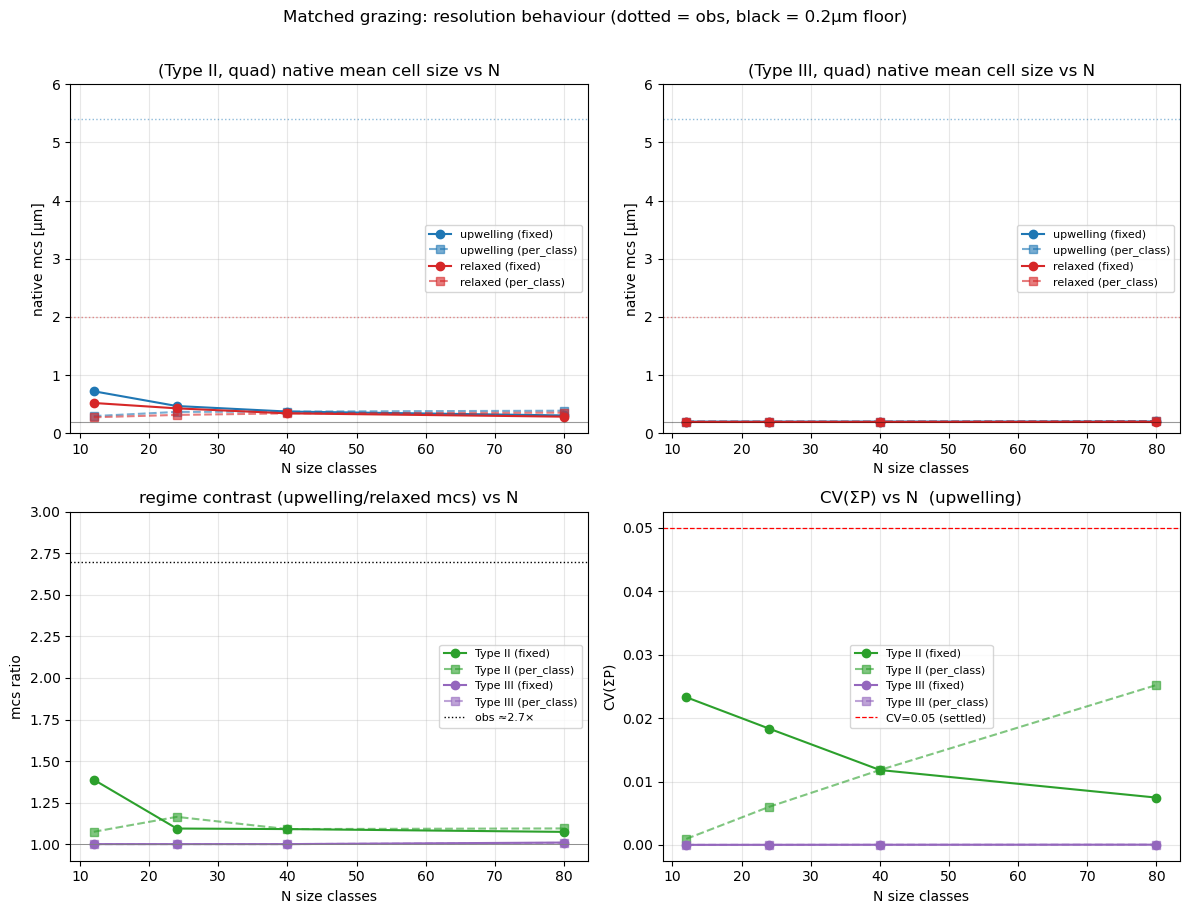

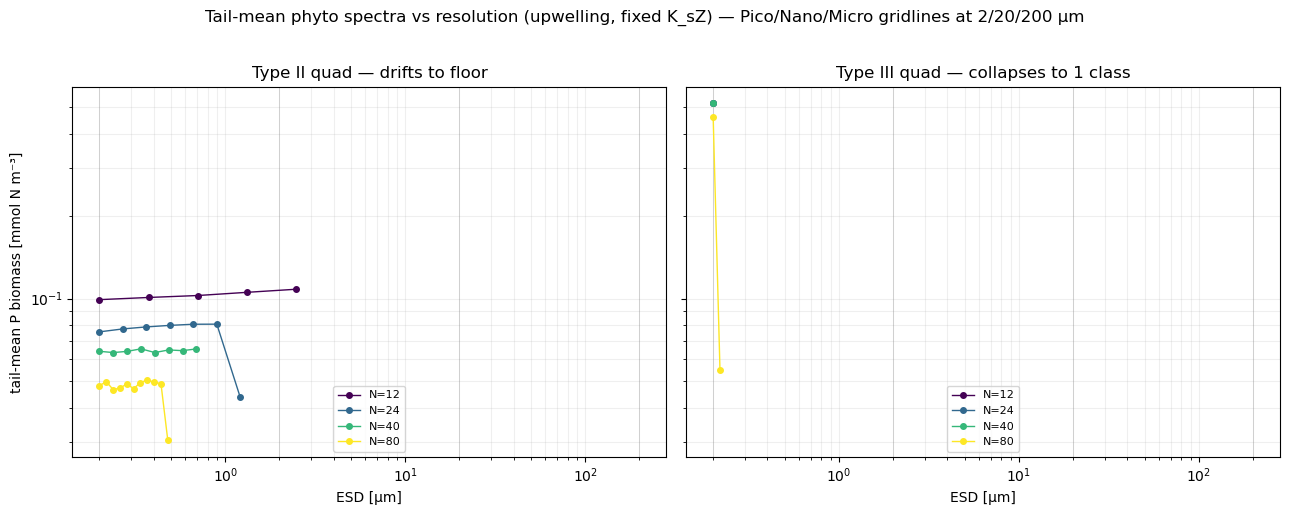

In [5]:
# ── Cell 5 — visualize the matched 2×2 × resolution scan ─────────────────────
import matplotlib.pyplot as plt
import numpy as np

UP_OBS, REL_OBS, FLOOR = 5.4, 2.0, 0.2          # obs medians (µm), grid floor
ser = lambda res, rn, rp, cl, mt: [res[(rn, N, rp, cl)][mt] for N in N_LIST]
ratio = lambda res, rp, cl: [res[('upwelling', N, rp, cl)]['mcs_native'] /
                             res[('relaxed', N, rp, cl)]['mcs_native'] for N in N_LIST]

# ---- Figure 1: convergence, contrast, stability (quad closure; lin ~identical) ----
fig, ax = plt.subplots(2, 2, figsize=(12, 9))
for axx, resp in zip((ax[0, 0], ax[0, 1]), ('II', 'III')):
    for rn, col in (('upwelling', 'C0'), ('relaxed', 'C3')):
        axx.plot(N_LIST, ser(SWEEP['fixed'], rn, resp, 'quad', 'mcs_native'),
                 'o-', color=col, label=f'{rn} (fixed)')
        axx.plot(N_LIST, ser(SWEEP['per_class'], rn, resp, 'quad', 'mcs_native'),
                 's--', color=col, alpha=0.6, label=f'{rn} (per_class)')
    axx.axhline(UP_OBS, color='C0', ls=':', lw=1, alpha=0.5)
    axx.axhline(REL_OBS, color='C3', ls=':', lw=1, alpha=0.5)
    axx.axhline(FLOOR, color='k', ls='-', lw=0.8, alpha=0.4)
    axx.set(title=f'(Type {resp}, quad) native mean cell size vs N',
            xlabel='N size classes', ylabel='native mcs [µm]', ylim=(0, 6))
    axx.legend(fontsize=8); axx.grid(alpha=0.3)

for resp, c in (('II', 'C2'), ('III', 'C4')):
    ax[1, 0].plot(N_LIST, ratio(SWEEP['fixed'], resp, 'quad'), 'o-', color=c,
                  label=f'Type {resp} (fixed)')
    ax[1, 0].plot(N_LIST, ratio(SWEEP['per_class'], resp, 'quad'), 's--', color=c,
                  alpha=0.6, label=f'Type {resp} (per_class)')
ax[1, 0].axhline(UP_OBS / REL_OBS, color='k', ls=':', lw=1, label=f'obs ≈{UP_OBS/REL_OBS:.1f}×')
ax[1, 0].axhline(1.0, color='grey', lw=0.6)
ax[1, 0].set(title='regime contrast (upwelling/relaxed mcs) vs N',
             xlabel='N size classes', ylabel='mcs ratio', ylim=(0.9, 3.0))
ax[1, 0].legend(fontsize=8); ax[1, 0].grid(alpha=0.3)

for resp, c in (('II', 'C2'), ('III', 'C4')):
    ax[1, 1].plot(N_LIST, ser(SWEEP['fixed'], 'upwelling', resp, 'quad', 'cv_sumP'),
                  'o-', color=c, label=f'Type {resp} (fixed)')
    ax[1, 1].plot(N_LIST, ser(SWEEP['per_class'], 'upwelling', resp, 'quad', 'cv_sumP'),
                  's--', color=c, alpha=0.6, label=f'Type {resp} (per_class)')
ax[1, 1].axhline(0.05, color='red', ls='--', lw=0.9, label='CV=0.05 (settled)')
ax[1, 1].set(title='CV(ΣP) vs N  (upwelling)',
             xlabel='N size classes', ylabel='CV(ΣP)')
ax[1, 1].legend(fontsize=8); ax[1, 1].grid(alpha=0.3)
plt.suptitle('Matched grazing: resolution behaviour (dotted = obs, black = 0.2µm floor)',
             y=1.01); plt.tight_layout(); plt.show()

# ---- Figure 2: tail-mean spectra across N (the resolution artifact, upwelling) ----
fig, ax = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
cmap = plt.cm.viridis(np.linspace(0, 1, len(N_LIST)))
for axx, resp, ttl in zip(ax, ('II', 'III'),
                          ('Type II quad — drifts to floor', 'Type III quad — collapses to 1 class')):
    for axv in (0.2, 2.0, 20.0, 200.0):
        axx.axvline(axv, color='grey', lw=0.5, alpha=0.4)
    for k, N in enumerate(N_LIST):
        d = SWEEP['fixed'][('upwelling', N, resp, 'quad')]
        msk = d['P_tail'] > 1e-10
        axx.loglog(d['esd'][msk], d['P_tail'][msk], 'o-', color=cmap[k],
                   ms=4, lw=1, label=f'N={N}')
    axx.set(title=ttl, xlabel='ESD [µm]')
    axx.legend(fontsize=8); axx.grid(alpha=0.2, which='both')
ax[0].set_ylabel('tail-mean P biomass [mmol N m⁻³]')
plt.suptitle('Tail-mean phyto spectra vs resolution (upwelling, fixed K_sZ) — '
             'Pico/Nano/Micro gridlines at 2/20/200 µm', y=1.02)
plt.tight_layout(); plt.show()

In [6]:
# ── Cell 6 — distributed-grazing builder (np_comps group-flux) + smoke ────────
import numpy as np
from np_comps import GrazingMatrix_TypeII, GrazingMatrix_TypeIII, GrazingRouter

THETA_OPT, SIGMA_LOG = 10.0, 0.25
IMAX_DIST, KSZ_DIST  = 3.0, 3.0          # uniform (Banas / Correction.md settled)

def compute_phiPZ(p, z, mode, theta_opt=THETA_OPT, sigma_log=SIGMA_LOG):
    n_P, n_Z = len(p), len(z)
    prey = np.concatenate([p, z])
    log_ratio = np.log10(z[None, :] / prey[:, None])
    kernel = np.exp(-((log_ratio - np.log10(theta_opt)) ** 2) / (2 * sigma_log ** 2))
    phi = np.zeros((n_P + n_Z, n_Z))
    if mode == 'matched':
        for j in range(n_Z): phi[j, j] = 1.0
    elif mode == 'herb':
        phi[:n_P, :] = kernel[:n_P, :]
    elif mode == 'omni':
        phi[:] = kernel
        for j in range(n_Z): phi[n_P + j, j] = 0.0
    else:
        raise ValueError(mode)
    return phi

GRAZ_DIST = {'II': GrazingMatrix_TypeII, 'III': GrazingMatrix_TypeIII}

def build_setup_dist(N, response, mode, fn=cbs.FN_DEFAULT, de=cbs.DE_DEFAULT):
    p = np.logspace(np.log10(ESD_MIN), np.log10(ESD_MAX), N)
    z = ZOO_RATIO * p
    mu = 1.36 * p ** (-0.16); ks = 0.33 * p ** (0.48)
    phi = compute_phiPZ(p, z, mode)
    model = xso.create({
        'Nutrient': Nutrient, 'Phytoplankton': PhytoSizeSpectrum,
        'Zooplankton': ZooSizeSpectrum, 'Inflow': StockNutrientSupply,
        'Growth': MonodGrowth_NP, 'Grazing': GRAZ_DIST[response],
        'GrazingRouter': GrazingRouter, 'PhytoLoss': PhytoLinearLoss_recycled,
        'ZooLoss': ZooQuadraticLoss_recycled, 'PhytoSinking': PhytoSinking_export,
    })
    iv = {
        'Nutrient':      {'value_label': 'N', 'value_init': 1.0},
        'Phytoplankton': {'biomass_label': 'P', 'biomass_init': np.full(N, 1e-3),
                          'phyto_esd_index': p.tolist(), 'phyto_esd_label': 'phyto_esd'},
        'Zooplankton':   {'biomass_label': 'Z', 'biomass_init': np.full(N, 1e-3),
                          'zoo_esd_index': z.tolist(), 'zoo_esd_label': 'zoo_esd'},
        'Inflow':        {'var': 'N', 'FN': fn, 'de': de, 'de_label': 'de'},
        'Growth':        {'resource': 'N', 'consumer': 'P', 'mu_max': mu, 'halfsat': ks},
        'Grazing':       {'resource': 'P', 'consumer': 'Z', 'phiPZ': phi,
                          'Imax': np.full(N, IMAX_DIST), 'KsZ': KSZ_DIST},
        'GrazingRouter': {'grazed_phyto': 'P', 'grazed_zoo': 'Z',
                          'assimilated_consumer': 'Z', 'excreted_nutrient': 'N',
                          'gamma': GAMMA},
        'PhytoLoss':     {'population': 'P', 'nutrient': 'N', 'rate': np.full(N, LAMBDA)},
        'ZooLoss':       {'population': 'Z', 'nutrient': 'N', 'rate': M_Z},
        'PhytoSinking':  {'population': 'P', 'w_sink': W_SINK, 'de': 'de'},
    }
    setup = xso.setup(solver='solve_ivp', model=model, time=cbs.ivp_time_array,
                      input_vars=iv, solver_kwargs=cbs.IVP_SOLVER_KWARGS)
    meta = dict(N=N, response=response, mode=mode, phyto_esd=p, zoo_esd=z,
                KsZ=np.full(N, KSZ_DIST))
    return model, setup, meta

# smoke: omni Type III at N=12, upwelling forcing
_m, _s, _meta = build_setup_dist(12, 'III', 'omni',
                                 FORC['upwelling']['Inflow__FN'], FORC['upwelling']['Inflow__de'])
_r = summarize_run(rbd.run_setup(_m, _s), _meta)
print(f"smoke omni-TypeIII N=12 upwelling: mcs={_r['mcs_native']:.2f}µm  "
      f"CV(ΣP)={_r['cv_sumP']:.3f}  ΣP={_r['sumP']:.3f}  act_P={_r['n_active_P']}/12")
print('if this prints sensibly, run Cell 7.')

smoke omni-TypeIII N=12 upwelling: mcs=0.20µm  CV(ΣP)=0.000  ΣP=0.516  act_P=1/12
if this prints sensibly, run Cell 7.


In [7]:
# ── Cell 7 — distributed sweep: {matched,herb,omni} × {II,III} × quad × N × regime ──
MODES = ['matched', 'herb', 'omni']

def run_sweep_dist(N_LIST, TAIL=1000, verbose=True):
    builds = {(N, rp, md): build_setup_dist(N, rp, md)
              for N in N_LIST for rp in ('II', 'III') for md in MODES}
    res = {}
    for rname, f in FORC.items():
        ov = {'Inflow': {'FN': f['Inflow__FN'], 'de': f['Inflow__de']}}
        for N in N_LIST:
            for rp in ('II', 'III'):
                for md in MODES:
                    m, s, meta = builds[(N, rp, md)]
                    res[(rname, N, rp, md)] = summarize_run(rbd.run_setup(m, s, ov), meta, tail=TAIL)
            if verbose:
                print(f'  {rname:10s} N={N:3d} done')
    return res

res_dist = run_sweep_dist(N_LIST)

print('\nNATIVE MEAN CELL SIZE [µm]  (rows: mode×response×regime, cols: N)')
print('  construct            ' + ''.join(f'{("N="+str(N)):>9s}' for N in N_LIST))
for md in MODES:
    for rp in ('II', 'III'):
        for rn in ('upwelling', 'relaxed'):
            vals = ''.join(f'{res_dist[(rn,N,rp,md)]["mcs_native"]:9.2f}' for N in N_LIST)
            print(f'  {md:8s} T{rp:3s} {rn:9s}' + vals)

print('\nREGIME CONTRAST native mcs (upwelling/relaxed)  vs N')
print('  construct      ' + ''.join(f'{("N="+str(N)):>9s}' for N in N_LIST))
for md in MODES:
    for rp in ('II', 'III'):
        vals = ''.join(f'{res_dist[("upwelling",N,rp,md)]["mcs_native"]/res_dist[("relaxed",N,rp,md)]["mcs_native"]:9.2f}'
                       for N in N_LIST)
        print(f'  {md:8s} T{rp:3s} ' + vals)

print('\nCV(ΣP) upwelling  vs N   /   active_P upwelling vs N')
for md in MODES:
    for rp in ('II', 'III'):
        cv = ''.join(f'{res_dist[("upwelling",N,rp,md)]["cv_sumP"]:7.3f}' for N in N_LIST)
        ap = ','.join(str(res_dist[("upwelling",N,rp,md)]["n_active_P"]) for N in N_LIST)
        print(f'  {md:8s} T{rp:3s} CV[{cv} ]  act_P[{ap}]')

  upwelling  N= 12 done
  upwelling  N= 24 done
  upwelling  N= 40 done
  upwelling  N= 80 done
  relaxed    N= 12 done
  relaxed    N= 24 done
  relaxed    N= 40 done
  relaxed    N= 80 done

NATIVE MEAN CELL SIZE [µm]  (rows: mode×response×regime, cols: N)
  construct                 N=12     N=24     N=40     N=80
  matched  TII  upwelling     0.37     0.31     0.29     0.26
  matched  TII  relaxed       0.37     0.31     0.29     0.25
  matched  TIII upwelling     0.20     0.21     0.21     0.21
  matched  TIII relaxed       0.20     0.20     0.20     0.20
  herb     TII  upwelling     0.50     0.46     0.50     0.50
  herb     TII  relaxed       0.38     0.42     0.41     0.40
  herb     TIII upwelling     0.20     0.20     0.20     0.20
  herb     TIII relaxed       0.20     0.20     0.20     0.20
  omni     TII  upwelling     0.20     0.20     0.20     0.20
  omni     TII  relaxed       0.20     0.20     0.20     0.20
  omni     TIII upwelling     0.20     0.20     0.20     0.20

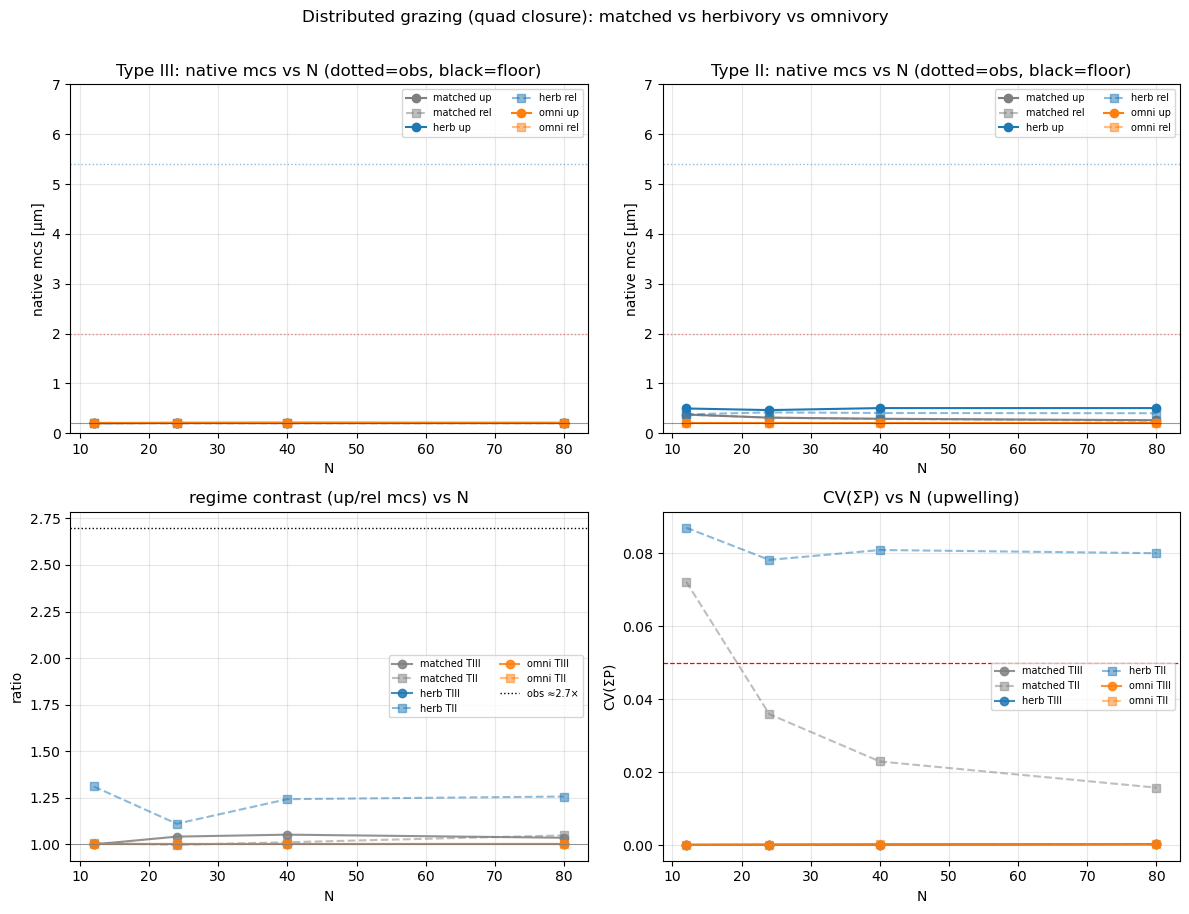

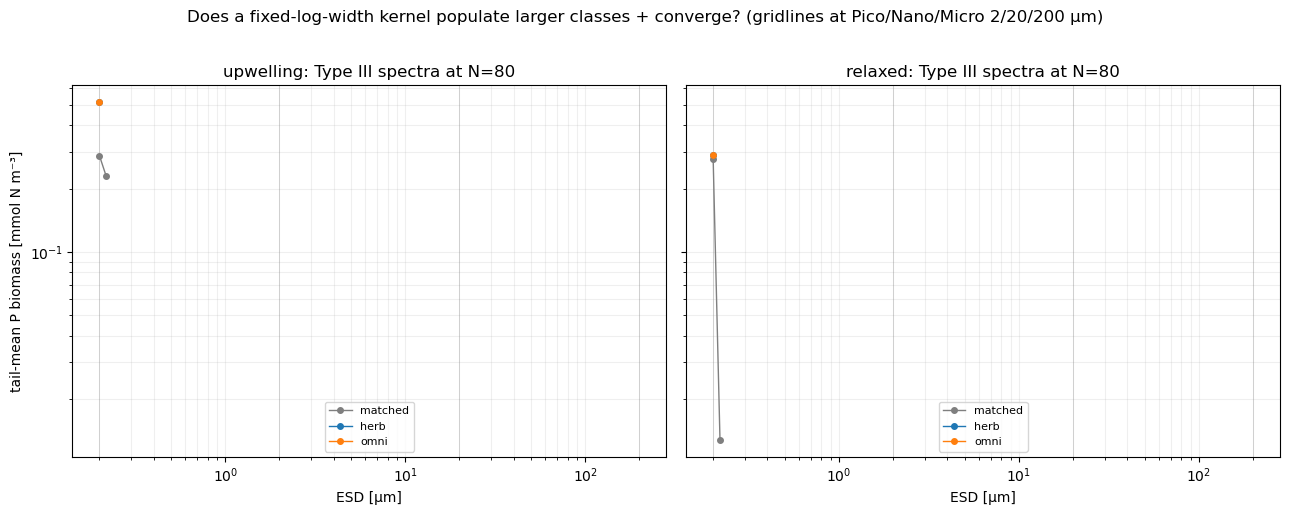

In [8]:
# ── Cell 8 — visualize distributed scan: convergence, contrast, spectra ──────
import matplotlib.pyplot as plt
MODE_COL = {'matched': 'C7', 'herb': 'C0', 'omni': 'C1'}
sd = lambda rn, N, rp, md, mt: res_dist[(rn, N, rp, md)][mt]

fig, ax = plt.subplots(2, 2, figsize=(12, 9))
for axx, rp in zip((ax[0, 0], ax[0, 1]), ('III', 'II')):
    for md in MODES:
        axx.plot(N_LIST, [sd('upwelling', N, rp, md, 'mcs_native') for N in N_LIST],
                 'o-', color=MODE_COL[md], label=f'{md} up')
        axx.plot(N_LIST, [sd('relaxed', N, rp, md, 'mcs_native') for N in N_LIST],
                 's--', color=MODE_COL[md], alpha=0.5, label=f'{md} rel')
    axx.axhline(5.4, color='C0', ls=':', lw=1, alpha=0.5)
    axx.axhline(2.0, color='C3', ls=':', lw=1, alpha=0.5)
    axx.axhline(0.2, color='k', lw=0.8, alpha=0.4)
    axx.set(title=f'Type {rp}: native mcs vs N (dotted=obs, black=floor)',
            xlabel='N', ylabel='native mcs [µm]', ylim=(0, 7))
    axx.legend(fontsize=7, ncol=2); axx.grid(alpha=0.3)

for md in MODES:
    for rp, ls in (('III', 'o-'), ('II', 's--')):
        ax[1, 0].plot(N_LIST, [sd('upwelling', N, rp, md, 'mcs_native') /
                               sd('relaxed', N, rp, md, 'mcs_native') for N in N_LIST],
                      ls, color=MODE_COL[md], alpha=0.85 if rp == 'III' else 0.5,
                      label=f'{md} T{rp}')
ax[1, 0].axhline(5.4 / 2.0, color='k', ls=':', lw=1, label='obs ≈2.7×')
ax[1, 0].axhline(1.0, color='grey', lw=0.6)
ax[1, 0].set(title='regime contrast (up/rel mcs) vs N', xlabel='N', ylabel='ratio')
ax[1, 0].legend(fontsize=7, ncol=2); ax[1, 0].grid(alpha=0.3)

for md in MODES:
    for rp, ls in (('III', 'o-'), ('II', 's--')):
        ax[1, 1].plot(N_LIST, [sd('upwelling', N, rp, md, 'cv_sumP') for N in N_LIST],
                      ls, color=MODE_COL[md], alpha=0.85 if rp == 'III' else 0.5,
                      label=f'{md} T{rp}')
ax[1, 1].axhline(0.05, color='red', ls='--', lw=0.9)
ax[1, 1].set(title='CV(ΣP) vs N (upwelling)', xlabel='N', ylabel='CV(ΣP)')
ax[1, 1].legend(fontsize=7, ncol=2); ax[1, 1].grid(alpha=0.3)
plt.suptitle('Distributed grazing (quad closure): matched vs herbivory vs omnivory',
             y=1.01); plt.tight_layout(); plt.show()

# tail-mean spectra at N=80, Type III, 3 kernels (upwelling | relaxed)
fig, ax = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for axx, rn in zip(ax, ('upwelling', 'relaxed')):
    for axv in (0.2, 2.0, 20.0, 200.0):
        axx.axvline(axv, color='grey', lw=0.5, alpha=0.4)
    for md in MODES:
        d = res_dist[(rn, 80, 'III', md)]
        msk = d['P_tail'] > 1e-10
        axx.loglog(d['esd'][msk], d['P_tail'][msk], 'o-', color=MODE_COL[md],
                   ms=4, lw=1, label=md)
    axx.set(title=f'{rn}: Type III spectra at N=80', xlabel='ESD [µm]')
    axx.legend(fontsize=8); axx.grid(alpha=0.2, which='both')
ax[0].set_ylabel('tail-mean P biomass [mmol N m⁻³]')
plt.suptitle('Does a fixed-log-width kernel populate larger classes + converge? '
             '(gridlines at Pico/Nano/Micro 2/20/200 µm)', y=1.02)
plt.tight_layout(); plt.show()